# Data discovery & labeling
Last updated: _2022.06.09_

The goal of this notebook is to give a thorough __overview__ of the __provided data__, then prepare it for model training.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from tqdm import tqdm

In [2]:
df_raw = pd.read_parquet("input/dps_2022_21_brandid_2300_301_for_candidates.parquet", dtype_backend="pyarrow")

In [3]:
df_raw = df_raw.replace('NA', pd.NA)

In [4]:
print("There are {:,} rows and {:} columns in the raw data.".format(df_raw.shape[0], df_raw.shape[1]))
print("The dataset contains data from {:} to {:}.".format(df_raw['summary_date'].min(), df_raw['summary_date'].max()))

There are 545,488 rows and 51 columns in the raw data.
The dataset contains data from 2021-01-01 to 2022-12-31.


## Descriptives

In [5]:
df_raw['accountid'].nunique()

2000

In [6]:
df_raw['accountid'].info()

<class 'pandas.Series'>
RangeIndex: 545488 entries, 0 to 545487
Series name: accountid
Non-Null Count   Dtype         
--------------   -----         
545488 non-null  int64[pyarrow]
dtypes: int64[pyarrow](1)
memory usage: 4.2 MB


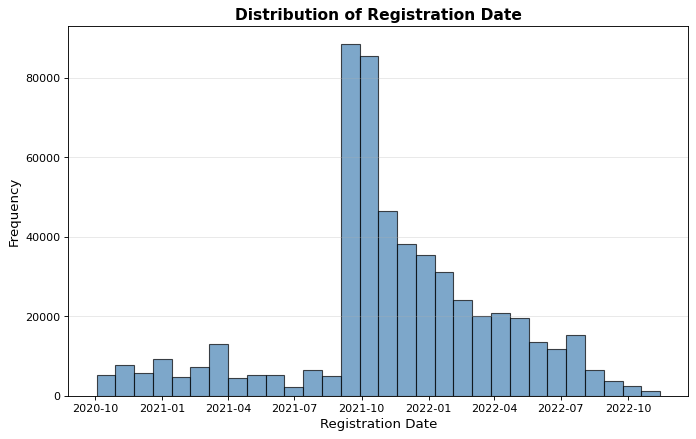

In [7]:
plt.figure(figsize=(10, 6), dpi=80)
ax = plt.gca()

ax.hist(df_raw['registration_date'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Registration Date', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Registration Date', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

In [8]:
df_raw['brandid'].value_counts()

brandid
300     407970
2300    137518
Name: count, dtype: int64[pyarrow]

In [9]:
df_raw['agp_brand'].value_counts()

agp_brand
Heart Bingo     407970
Parimatch UK    137518
Name: count, dtype: int64[pyarrow]

In [10]:
# Check whether brandid and agp_brand are functionally linked
brand_to_agp = df_raw.groupby('brandid')['agp_brand'].nunique(dropna=False).sort_values(ascending=False)
agp_to_brand = df_raw.groupby('agp_brand')['brandid'].nunique(dropna=False).sort_values(ascending=False)

print(f"Each brandid maps to a single agp_brand: {(brand_to_agp <= 1).all()}")
print(f"Each agp_brand maps to a single brandid: {(agp_to_brand <= 1).all()}")

ambiguous_brand_ids = brand_to_agp[brand_to_agp > 1]
ambiguous_agp_brands = agp_to_brand[agp_to_brand > 1]

print(f"brandid values linked to multiple agp_brand values: {len(ambiguous_brand_ids)}")
print(f"agp_brand values linked to multiple brandid values: {len(ambiguous_agp_brands)}")

if not ambiguous_brand_ids.empty:
    display(
        df_raw[df_raw['brandid'].isin(ambiguous_brand_ids.index)]
        [['brandid', 'agp_brand']]
        .drop_duplicates()
        .sort_values(['brandid', 'agp_brand'])
        .head(25)
    )

if not ambiguous_agp_brands.empty:
    display(
        df_raw[df_raw['agp_brand'].isin(ambiguous_agp_brands.index)]
        [['agp_brand', 'brandid']]
        .drop_duplicates()
        .sort_values(['agp_brand', 'brandid'])
        .head(25)
    )

Each brandid maps to a single agp_brand: True
Each agp_brand maps to a single brandid: True
brandid values linked to multiple agp_brand values: 0
agp_brand values linked to multiple brandid values: 0


In [11]:
df_raw['reporting_region'].value_counts()

reporting_region
United Kingdom    544936
Ireland              552
Name: count, dtype: int64[pyarrow]

In [12]:
df_raw['market'].value_counts()

market
Heart Bingo     407418
Parimatch UK    137518
Ireland            552
Name: count, dtype: int64[pyarrow]

In [13]:
df_raw['reg_channel'].value_counts(dropna=False)

reg_channel
Mobile    545488
Name: count, dtype: int64[pyarrow]

In [14]:
df_raw['reg_channel'].describe()

count     545488
unique         1
top       Mobile
freq      545488
Name: reg_channel, dtype: object

<div class="alert alert-block alert-warning">
    <b>reg_channel</b> is where the customer originally registered on, will be dropped as it has only 1 value.
</div>

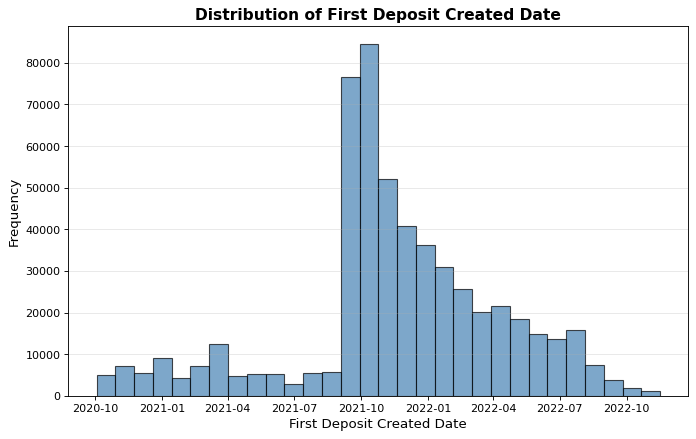

In [15]:
plt.figure(figsize=(10, 6), dpi=80)
ax = plt.gca()

ax.hist(df_raw['firstdeposit_createddate'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('First Deposit Created Date', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of First Deposit Created Date', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

There is a huge spike in registrations starting October 2021.

In [16]:
df_raw['reg_prod'].value_counts()

reg_prod
eGaming    321833
Bingo      118471
Sports     105184
Name: count, dtype: int64[pyarrow]

In [17]:
df_raw['foundation_category'].value_counts()

foundation_category
NewPlayer    288632
Paint        252060
Plaster        4758
Name: count, dtype: int64[pyarrow]

In [18]:
df_raw['account_tier'].value_counts()

account_tier
VALUED            261129
Premium           137744
MEDIUM             33050
NEW                25800
WINNERS            20486
AVERAGE            18353
LOW                17835
ABOVE AVERAGE      12601
LOWEST              9953
NO VALUE            4023
NEW WATCH LIST      2722
NON DEPOSITOR       1727
CLOSED                65
Name: count, dtype: int64[pyarrow]

In [19]:
df_raw['ordinalposition'].value_counts()

ordinalposition
3     261129
2     137744
4      33050
10     25800
9      20486
6      18353
7      17835
5      12601
8       9953
12      4023
11      2722
13      1727
14        65
Name: count, dtype: int64[pyarrow]

Position of this tier in the hierarchy, the lower the better

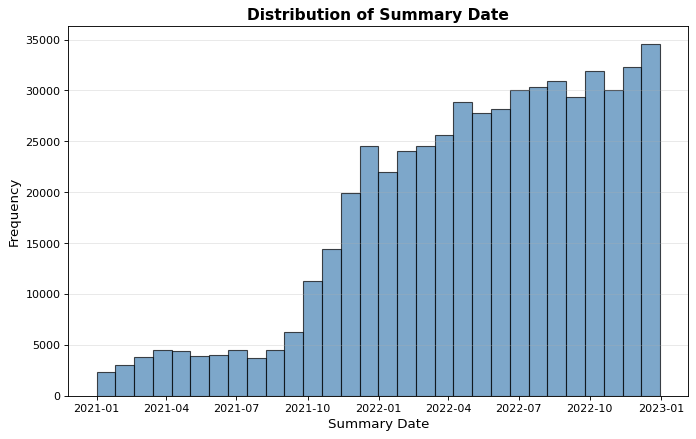

In [20]:
plt.figure(figsize=(10, 6), dpi=80)
ax = plt.gca()

ax.hist(df_raw['summary_date'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Summary Date', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Summary Date', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

In [21]:
df_raw['category'].value_counts()

category
eGaming    237480
Sports      73204
Bingo       58116
Name: count, dtype: int64[pyarrow]

In [22]:
df_raw['activity_channel'].value_counts()

activity_channel
Not Available     267016
Mobile             42554
Desktop            19425
Tablet               885
Not Applicable         9
Name: count, dtype: int64[pyarrow]

In [23]:
df_raw['secondary_product'].value_counts()[:10]

secondary_product
Slots           189024
Bingo            58116
Football         26329
Horse Racing     18239
Instant Win       5944
Roulette          4765
Wheel Games       3666
Blackjack         3236
Tennis            2234
Combination       2199
Name: count, dtype: int64[pyarrow]

In [24]:
df_raw['bet_type'].value_counts()

bet_type
RnG       208869
Others     58138
Single     41055
Combi      21827
Name: count, dtype: int64[pyarrow]

In [25]:
df_raw['productgroup'].value_counts()

productgroup
Casino            200628
Sportsbook         59790
Bingo              58116
Overall            18895
Live Casino         8241
Virtual Sports      1628
eSports             1464
Lottery               22
Name: count, dtype: int64[pyarrow]

In [26]:
df_raw['plc_turnover_gbp'].value_counts()

plc_turnover_gbp
0E-9              260296
10.000000000        8640
5.000000000         7865
20.000000000        6379
15.000000000        3053
                   ...  
824.350000000          1
898.130000000          1
2365.430000000         1
1371.530000000         1
102.310000000          1
Name: count, Length: 42248, dtype: int64[pyarrow]

In [27]:
df_raw['plc_turnover'].value_counts()

plc_turnover
0E-9              260296
10.000000000        8644
5.000000000         7866
20.000000000        6380
15.000000000        3054
                   ...  
824.350000000          1
898.130000000          1
2365.430000000         1
1371.530000000         1
102.310000000          1
Name: count, Length: 42028, dtype: int64[pyarrow]

In [28]:
df_raw[df_raw['plc_turnover_gbp'] != df_raw['plc_turnover']][['plc_turnover_gbp', 'plc_turnover']]

,plc_turnover_gbp,plc_turnover
323,26.015186000,30.200000000
1384,1.224595000,1.450000000
1385,15.497456000,18.350000000
2864,146.474639875,170.099999000
10658,1.059247000,1.230000000
...,...,...
539517,17.302106200,20.010000000
541920,33.014217000,37.470000000
541921,0.881084000,1.000000000
542069,82.910004200,94.100000000


In [29]:
df_raw[df_raw['plc_turnover_gbp'] > 0]['plc_turnover_gbp'].mean(), df_raw[df_raw['plc_turnover'] > 0]['plc_turnover'].mean()

(Decimal('185.081922122'), Decimal('185.092824216'))

In [30]:
df_raw[df_raw['plc_turnover_gbp'] > 0]['plc_turnover_gbp'].median(), df_raw[df_raw['plc_turnover'] > 0]['plc_turnover'].median()

(30.400000000000002, 30.400000000000002)

In [31]:
def trim_and_draw_boxplot(df, col, clipping_range=[0, 0.75], y_log=True):
    lower_bound = df[col].quantile(clipping_range[0])
    upper_bound = df[col].quantile(clipping_range[1])

    print("Keeping data points between {:.0f}th and {:.0f}th percentile ({:,.4f} - {:,.4f})".format(
        clipping_range[0]*100,
        clipping_range[1]*100,
        lower_bound,
        upper_bound
    ))

    df_trimmed = df[
        (df[col] <= upper_bound) &
        (lower_bound < df[col])
    ]

    # Calculating means
    print("Mean of `{:}`:\n- Original: {:>8,.4f}\n- Trimmed: {:>9,.4f}".format(
        col,
        df[col].mean(),
        df_trimmed[col].mean()
    ))
    
    # Boxplots
    fig, ax = plt.subplots(figsize=(8, 6))

    df.boxplot(column=col, ax=ax, positions=[1])
    df_trimmed.boxplot(column=col, ax=ax, positions=[2])

    ax.set_title('Comparison of `{:}` (Raw vs Trimmed)'.format(col), fontsize=14)
    ax.set_xlabel('Dataset')
    ax.set_ylabel(col)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Raw', 'Trimmed'])

    if y_log:
        plt.yscale('log')

    plt.suptitle('Boxplot Comparison Before and After Outlier Removal', fontsize=16)
    plt.show()

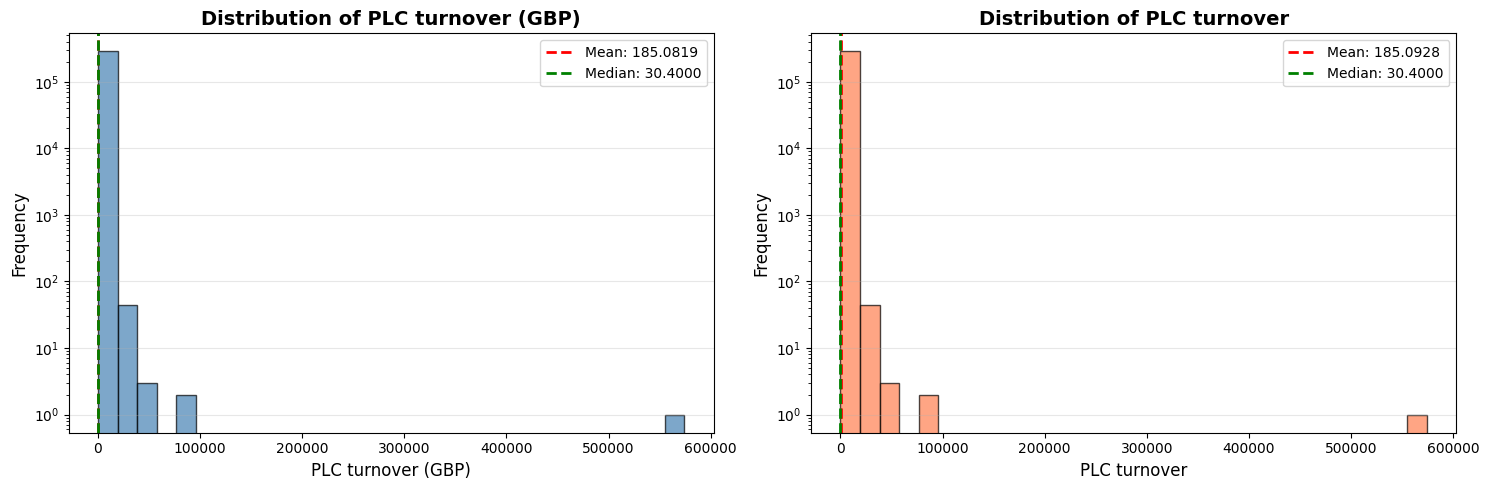

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# First histogram
ax1.hist(df_raw[df_raw['plc_turnover_gbp'] > 0]['plc_turnover_gbp'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax1.set_xlabel('PLC turnover (GBP)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of PLC turnover (GBP)', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add statistics
mean_progress = df_raw[df_raw['plc_turnover_gbp'] > 0]['plc_turnover_gbp'].mean()
median_progress = df_raw[df_raw['plc_turnover_gbp'] > 0]['plc_turnover_gbp'].median()
ax1.axvline(mean_progress, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_progress:.4f}')
ax1.axvline(median_progress, color='green', linestyle='--', linewidth=2, label=f'Median: {median_progress:.4f}')
ax1.legend()

# Second histogram
ax2.hist(df_raw[df_raw['plc_turnover'] > 0]['plc_turnover'], bins=30, color='coral', edgecolor='black', alpha=0.7, log=True)
ax2.set_xlabel('PLC turnover', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Distribution of PLC turnover', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add statistics
mean_fill = df_raw[df_raw['plc_turnover'] > 0]['plc_turnover'].mean()
median_fill = df_raw[df_raw['plc_turnover'] > 0]['plc_turnover'].median()
ax2.axvline(mean_fill, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_fill:.4f}')
ax2.axvline(median_fill, color='green', linestyle='--', linewidth=2, label=f'Median: {median_fill:.4f}')
ax2.legend()

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">
    As shown in the chart, the presence of an outlier of <b>plc_turnover_gbp</b> has a significant influence on the model’s behavior, and it may be appropriate to consider trimming the data to mitigate its impact.
</div>

In [33]:
df_raw['plc_turnover_gbp'] = df_raw['plc_turnover_gbp'].astype(float)

Keeping data points between 0th and 99th percentile (-2.0000 - 1,636.5955)
Mean of `plc_turnover_gbp`:
- Original:  96.7604
- Trimmed:   59.6938


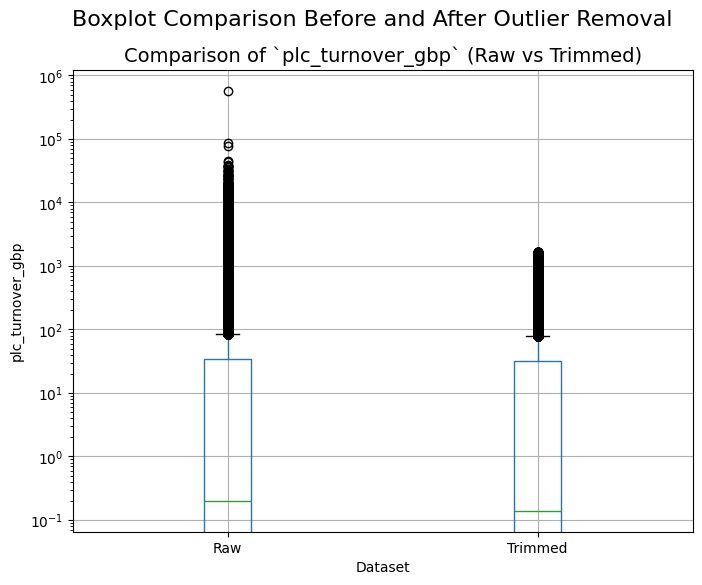

In [34]:
trim_and_draw_boxplot(df_raw, 'plc_turnover_gbp', clipping_range=[0, 0.99])

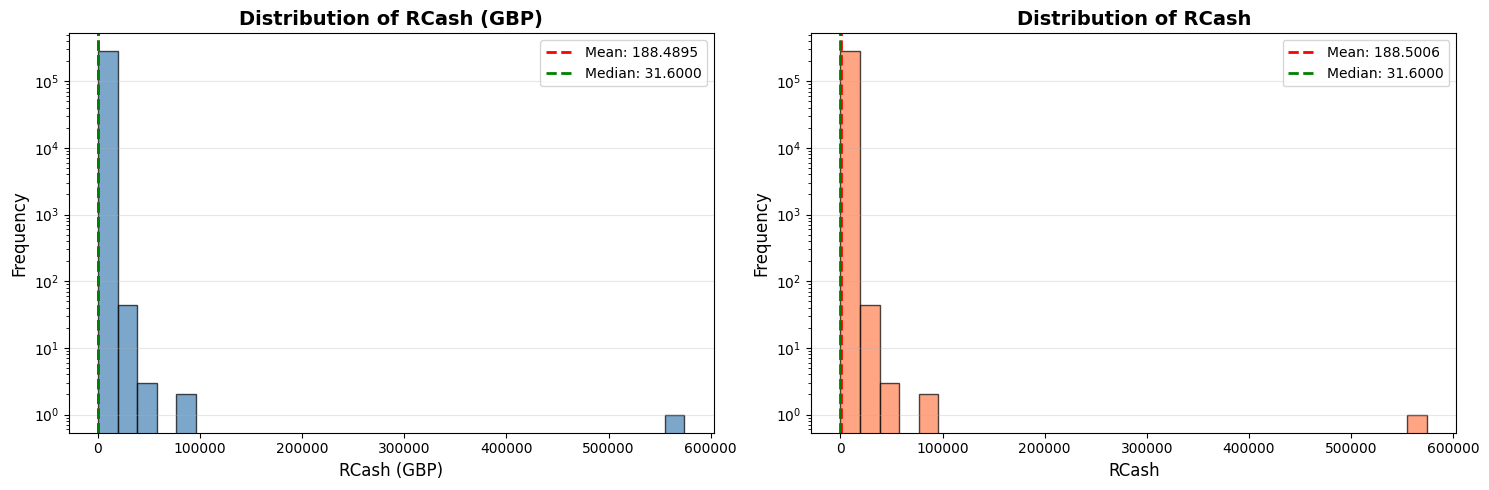

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# First histogram
ax1.hist(df_raw[df_raw['plc_turnover_gbp_rcash'] > 0]['plc_turnover_gbp_rcash'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax1.set_xlabel('RCash (GBP)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of RCash (GBP)', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add statistics
mean_progress = df_raw[df_raw['plc_turnover_gbp_rcash'] > 0]['plc_turnover_gbp_rcash'].mean()
median_progress = df_raw[df_raw['plc_turnover_gbp_rcash'] > 0]['plc_turnover_gbp_rcash'].median()
ax1.axvline(mean_progress, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_progress:.4f}')
ax1.axvline(median_progress, color='green', linestyle='--', linewidth=2, label=f'Median: {median_progress:.4f}')
ax1.legend()

# Second histogram
ax2.hist(df_raw[df_raw['plc_turnover_rcash'] > 0]['plc_turnover_rcash'], bins=30, color='coral', edgecolor='black', alpha=0.7, log=True)
ax2.set_xlabel('RCash', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Distribution of RCash', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add statistics
mean_fill = df_raw[df_raw['plc_turnover_rcash'] > 0]['plc_turnover_rcash'].mean()
median_fill = df_raw[df_raw['plc_turnover_rcash'] > 0]['plc_turnover_rcash'].median()
ax2.axvline(mean_fill, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_fill:.4f}')
ax2.axvline(median_fill, color='green', linestyle='--', linewidth=2, label=f'Median: {median_fill:.4f}')
ax2.legend()

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">
    As shown in the chart, the presence of an outlier of <b>plc_turnover_gbp_rcash</b> has a significant influence on the model’s behavior, and it may be appropriate to consider trimming the data to mitigate its impact.
</div>

In [36]:
df_raw['plc_turnover_gbp_rcash'] = df_raw['plc_turnover_gbp_rcash'].astype(float)

Keeping data points between 0th and 99th percentile (-2.0000 - 1,633.2000)
Mean of `plc_turnover_gbp_rcash`:
- Original:  96.3449
- Trimmed:   59.3045


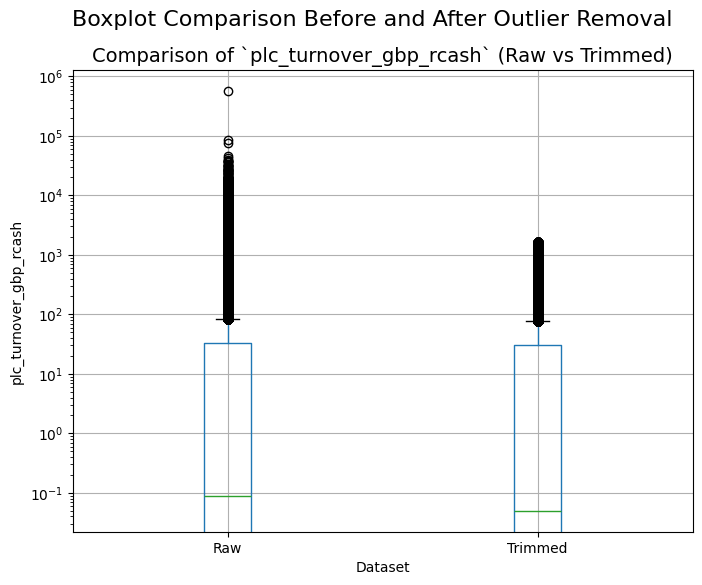

In [37]:
trim_and_draw_boxplot(df_raw, 'plc_turnover_gbp_rcash', clipping_range=[0, 0.99])

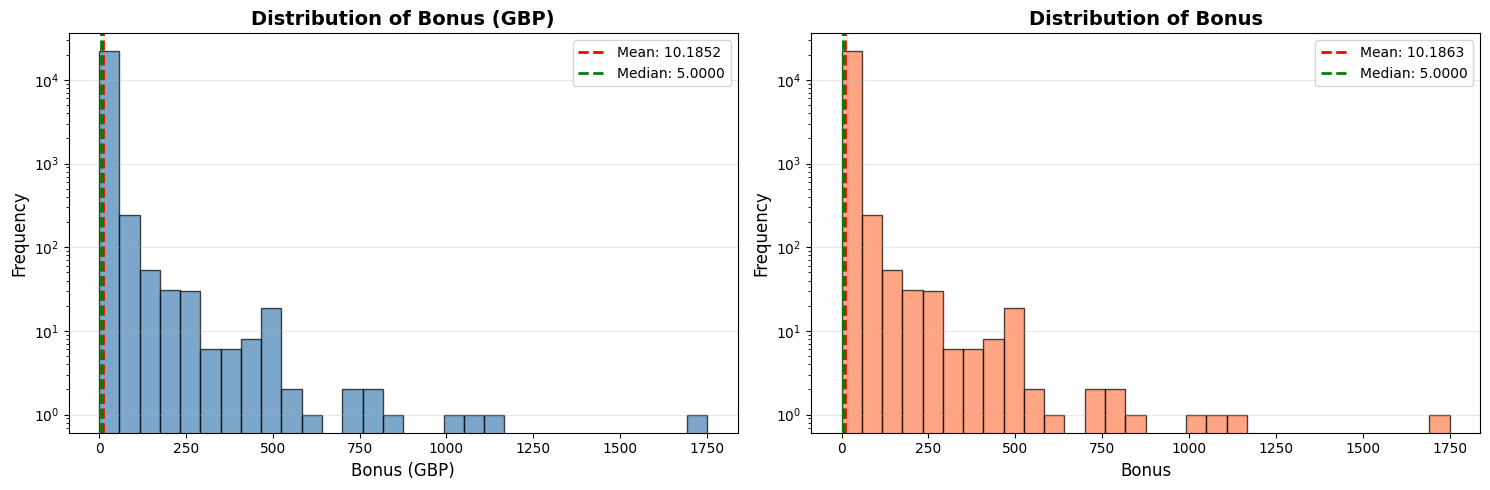

In [38]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# First histogram
ax1.hist(df_raw[df_raw['plc_turnover_gbp_bonus'] > 0]['plc_turnover_gbp_bonus'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax1.set_xlabel('Bonus (GBP)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of Bonus (GBP)', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add statistics
mean_progress = df_raw[df_raw['plc_turnover_gbp_bonus'] > 0]['plc_turnover_gbp_bonus'].mean()
median_progress = df_raw[df_raw['plc_turnover_gbp_bonus'] > 0]['plc_turnover_gbp_bonus'].median()
ax1.axvline(mean_progress, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_progress:.4f}')
ax1.axvline(median_progress, color='green', linestyle='--', linewidth=2, label=f'Median: {median_progress:.4f}')
ax1.legend()

# Second histogram
ax2.hist(df_raw[df_raw['plc_turnover_bonus'] > 0]['plc_turnover_bonus'], bins=30, color='coral', edgecolor='black', alpha=0.7, log=True)
ax2.set_xlabel('Bonus', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Distribution of Bonus', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add statistics
mean_fill = df_raw[df_raw['plc_turnover_bonus'] > 0]['plc_turnover_bonus'].mean()
median_fill = df_raw[df_raw['plc_turnover_bonus'] > 0]['plc_turnover_bonus'].median()
ax2.axvline(mean_fill, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_fill:.4f}')
ax2.axvline(median_fill, color='green', linestyle='--', linewidth=2, label=f'Median: {median_fill:.4f}')
ax2.legend()

plt.tight_layout()
plt.show()

In [39]:
df_raw['plc_turnover_gbp_bonus'] = df_raw['plc_turnover_gbp_bonus'].astype(float)

Keeping data points between 0th and 100th percentile (0.0000 - 1,400.5338)
Mean of `plc_turnover_gbp_bonus`:
- Original:   0.4155
- Trimmed:   10.1070


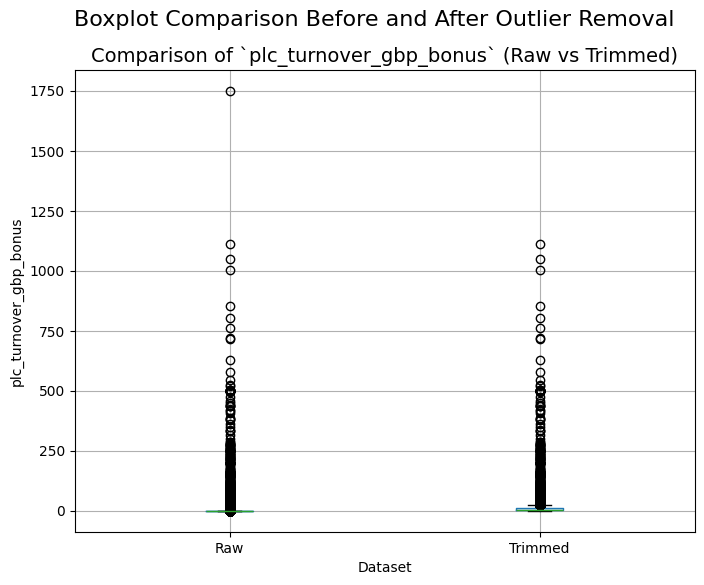

In [40]:
trim_and_draw_boxplot(df_raw, 'plc_turnover_gbp_bonus', clipping_range=[0, 0.999999], y_log=False)

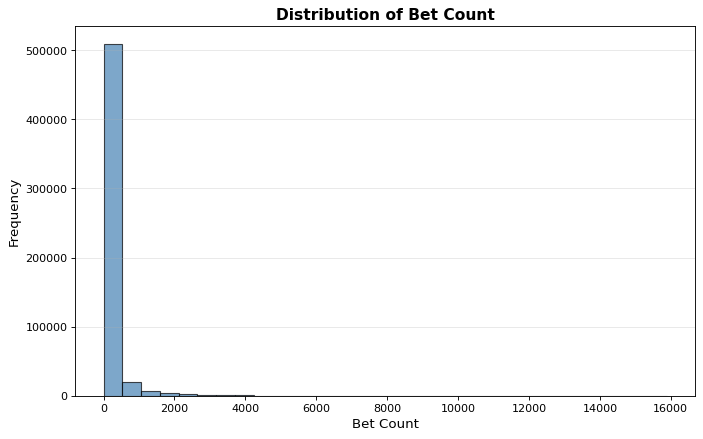

In [41]:
plt.figure(figsize=(10, 6), dpi=80)
ax = plt.gca()

ax.hist(df_raw['plc_betcount'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=False)
ax.set_xlabel('Bet Count', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Bet Count', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

In [42]:
df_raw['plc_betcount'] = df_raw['plc_betcount'].astype(float)

Keeping data points between 0th and 100th percentile (0.0000 - 7,630.7078)
Mean of `plc_betcount`:
- Original: 130.3045
- Trimmed:  218.8126


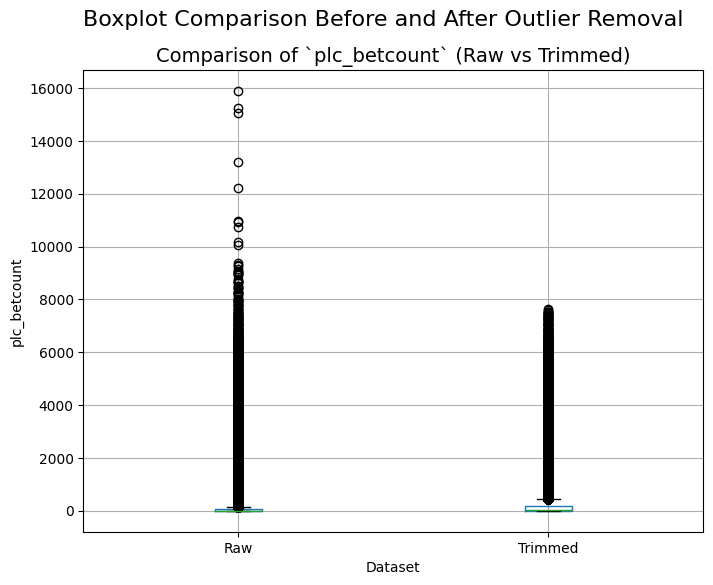

In [43]:
trim_and_draw_boxplot(df_raw, 'plc_betcount', clipping_range=[0, 0.9999], y_log=False)

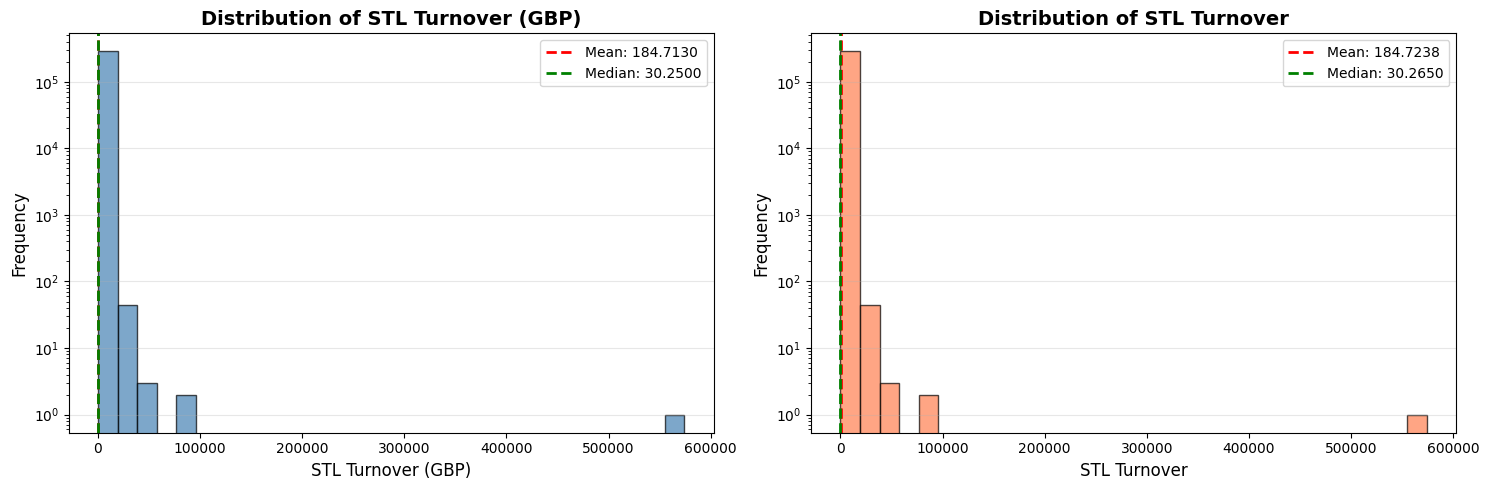

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# First histogram
ax1.hist(df_raw[df_raw['stl_turnover_gbp'] > 0]['stl_turnover_gbp'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax1.set_xlabel('STL Turnover (GBP)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of STL Turnover (GBP)', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add statistics
mean_progress = df_raw[df_raw['stl_turnover_gbp'] > 0]['stl_turnover_gbp'].mean()
median_progress = df_raw[df_raw['stl_turnover_gbp'] > 0]['stl_turnover_gbp'].median()
ax1.axvline(mean_progress, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_progress:.4f}')
ax1.axvline(median_progress, color='green', linestyle='--', linewidth=2, label=f'Median: {median_progress:.4f}')
ax1.legend()

# Second histogram
ax2.hist(df_raw[df_raw['stl_turnover'] > 0]['stl_turnover'], bins=30, color='coral', edgecolor='black', alpha=0.7, log=True)
ax2.set_xlabel('STL Turnover', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Distribution of STL Turnover', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add statistics
mean_fill = df_raw[df_raw['stl_turnover'] > 0]['stl_turnover'].mean()
median_fill = df_raw[df_raw['stl_turnover'] > 0]['stl_turnover'].median()
ax2.axvline(mean_fill, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_fill:.4f}')
ax2.axvline(median_fill, color='green', linestyle='--', linewidth=2, label=f'Median: {median_fill:.4f}')
ax2.legend()

plt.tight_layout()
plt.show()

In [45]:
df_raw['stl_turnover_gbp'] = df_raw['stl_turnover_gbp'].astype(float)

Keeping data points between 0th and 99th percentile (-2.0000 - 1,635.7171)
Mean of `stl_turnover_gbp`:
- Original:  96.7578
- Trimmed:   59.6830


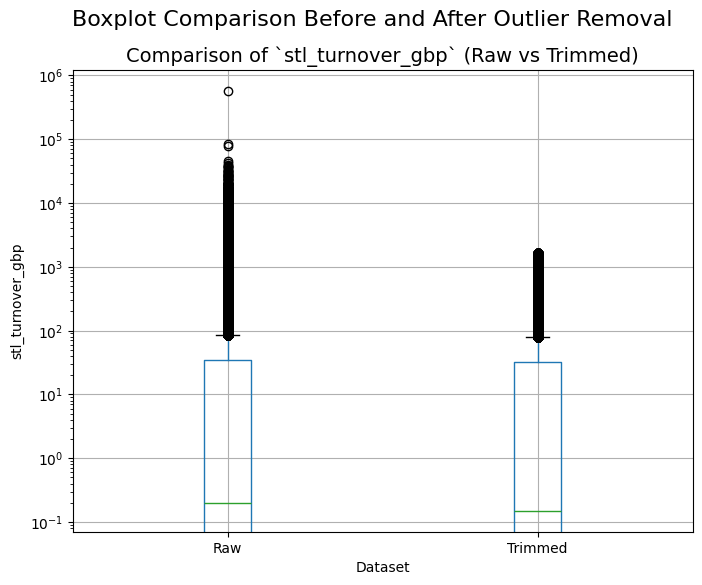

In [46]:
trim_and_draw_boxplot(df_raw, 'stl_turnover_gbp', clipping_range=[0, 0.99], y_log=True)

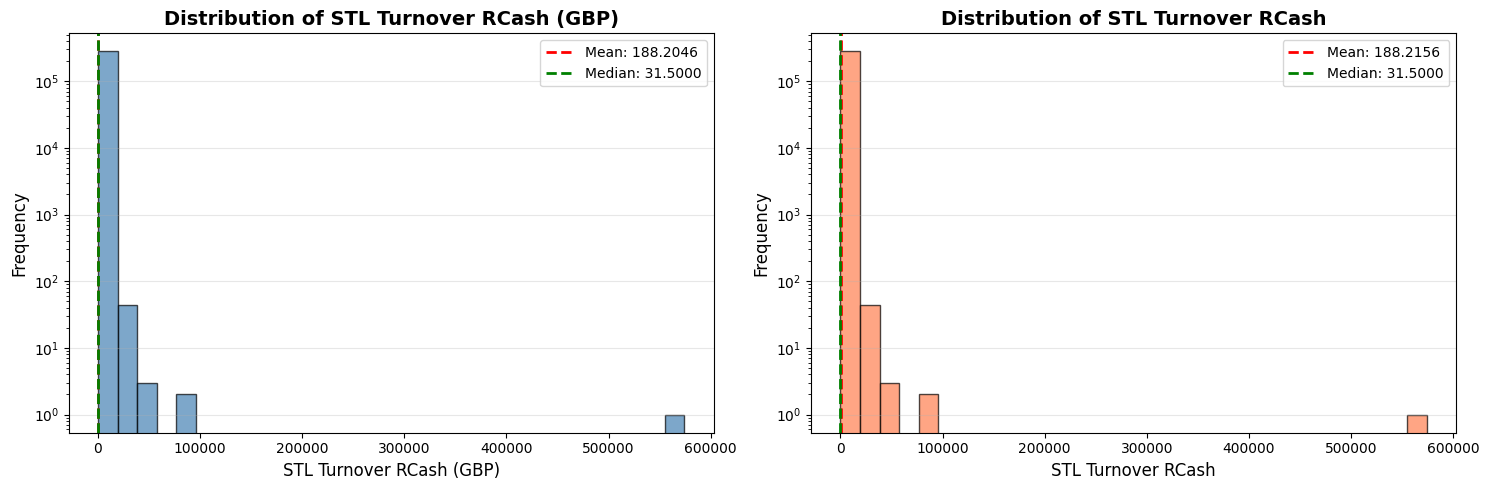

In [47]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# First histogram
ax1.hist(df_raw[df_raw['stl_turnover_gbp_rcash'] > 0]['stl_turnover_gbp_rcash'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax1.set_xlabel('STL Turnover RCash (GBP)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of STL Turnover RCash (GBP)', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add statistics
mean_progress = df_raw[df_raw['stl_turnover_gbp_rcash'] > 0]['stl_turnover_gbp_rcash'].mean()
median_progress = df_raw[df_raw['stl_turnover_gbp_rcash'] > 0]['stl_turnover_gbp_rcash'].median()
ax1.axvline(mean_progress, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_progress:.4f}')
ax1.axvline(median_progress, color='green', linestyle='--', linewidth=2, label=f'Median: {median_progress:.4f}')
ax1.legend()

# Second histogram
ax2.hist(df_raw[df_raw['stl_turnover_rcash'] > 0]['stl_turnover_rcash'], bins=30, color='coral', edgecolor='black', alpha=0.7, log=True)
ax2.set_xlabel('STL Turnover RCash', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Distribution of STL Turnover RCash', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add statistics
mean_fill = df_raw[df_raw['stl_turnover_rcash'] > 0]['stl_turnover_rcash'].mean()
median_fill = df_raw[df_raw['stl_turnover_rcash'] > 0]['stl_turnover_rcash'].median()
ax2.axvline(mean_fill, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_fill:.4f}')
ax2.axvline(median_fill, color='green', linestyle='--', linewidth=2, label=f'Median: {median_fill:.4f}')
ax2.legend()

plt.tight_layout()
plt.show()

In [48]:
df_raw['stl_turnover_gbp_rcash'] = df_raw['stl_turnover_gbp_rcash'].astype(float)

Keeping data points between 0th and 99th percentile (-2.0000 - 1,632.7651)
Mean of `stl_turnover_gbp_rcash`:
- Original:  96.3425
- Trimmed:   59.2909


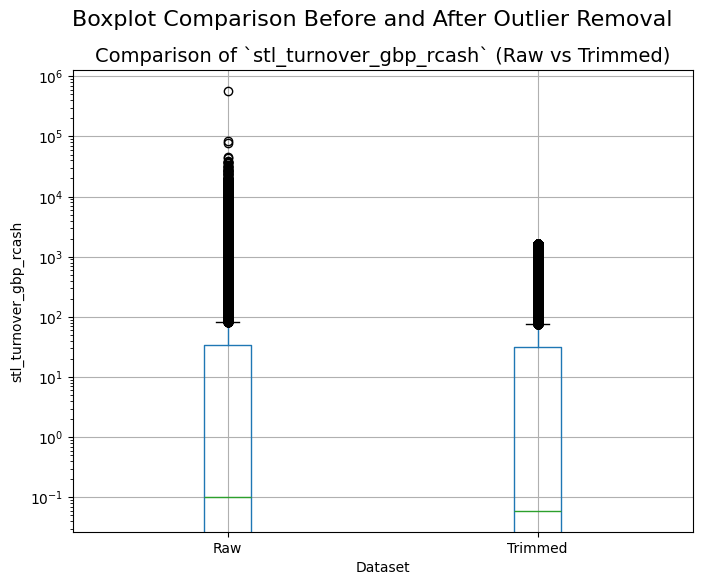

In [49]:
trim_and_draw_boxplot(df_raw, 'stl_turnover_gbp_rcash', clipping_range=[0, 0.99], y_log=True)

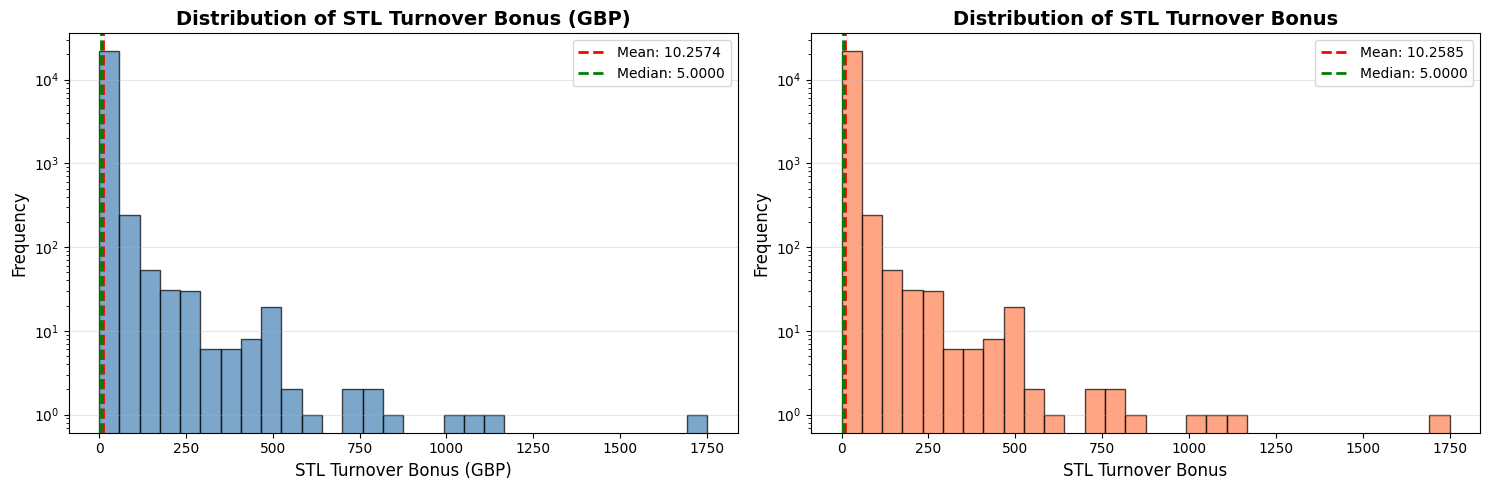

In [50]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# First histogram
ax1.hist(df_raw[df_raw['stl_turnover_gbp_bonus'] > 0]['stl_turnover_gbp_bonus'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax1.set_xlabel('STL Turnover Bonus (GBP)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of STL Turnover Bonus (GBP)', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add statistics
mean_progress = df_raw[df_raw['stl_turnover_gbp_bonus'] > 0]['stl_turnover_gbp_bonus'].mean()
median_progress = df_raw[df_raw['stl_turnover_gbp_bonus'] > 0]['stl_turnover_gbp_bonus'].median()
ax1.axvline(mean_progress, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_progress:.4f}')
ax1.axvline(median_progress, color='green', linestyle='--', linewidth=2, label=f'Median: {median_progress:.4f}')
ax1.legend()

# Second histogram
ax2.hist(df_raw[df_raw['stl_turnover_bonus'] > 0]['stl_turnover_bonus'], bins=30, color='coral', edgecolor='black', alpha=0.7, log=True)
ax2.set_xlabel('STL Turnover Bonus', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Distribution of STL Turnover Bonus', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add statistics
mean_fill = df_raw[df_raw['stl_turnover_bonus'] > 0]['stl_turnover_bonus'].mean()
median_fill = df_raw[df_raw['stl_turnover_bonus'] > 0]['stl_turnover_bonus'].median()
ax2.axvline(mean_fill, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_fill:.4f}')
ax2.axvline(median_fill, color='green', linestyle='--', linewidth=2, label=f'Median: {median_fill:.4f}')
ax2.legend()

plt.tight_layout()
plt.show()

In [51]:
df_raw['stl_turnover_gbp_bonus'] = df_raw['stl_turnover_gbp_bonus'].astype(float)

Keeping data points between 0th and 100th percentile (0.0000 - 1,400.5338)
Mean of `stl_turnover_gbp_bonus`:
- Original:   0.4154
- Trimmed:   10.1786


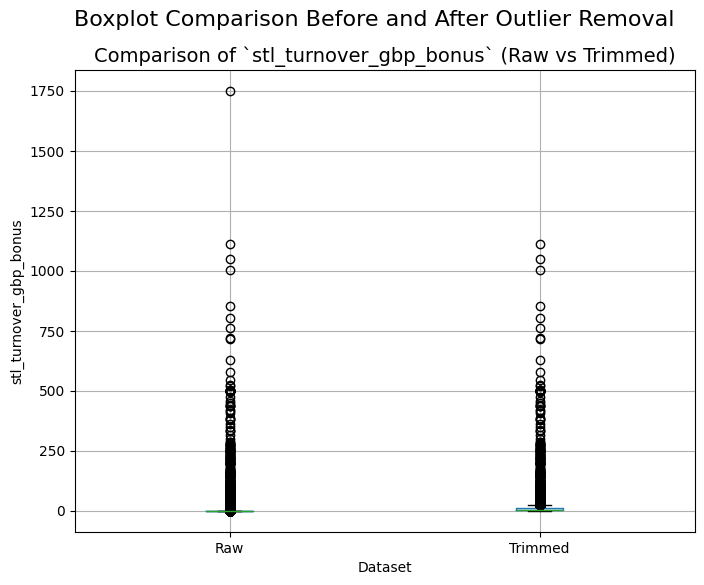

In [52]:
trim_and_draw_boxplot(df_raw, 'stl_turnover_gbp_bonus', clipping_range=[0, 0.999999], y_log=False)

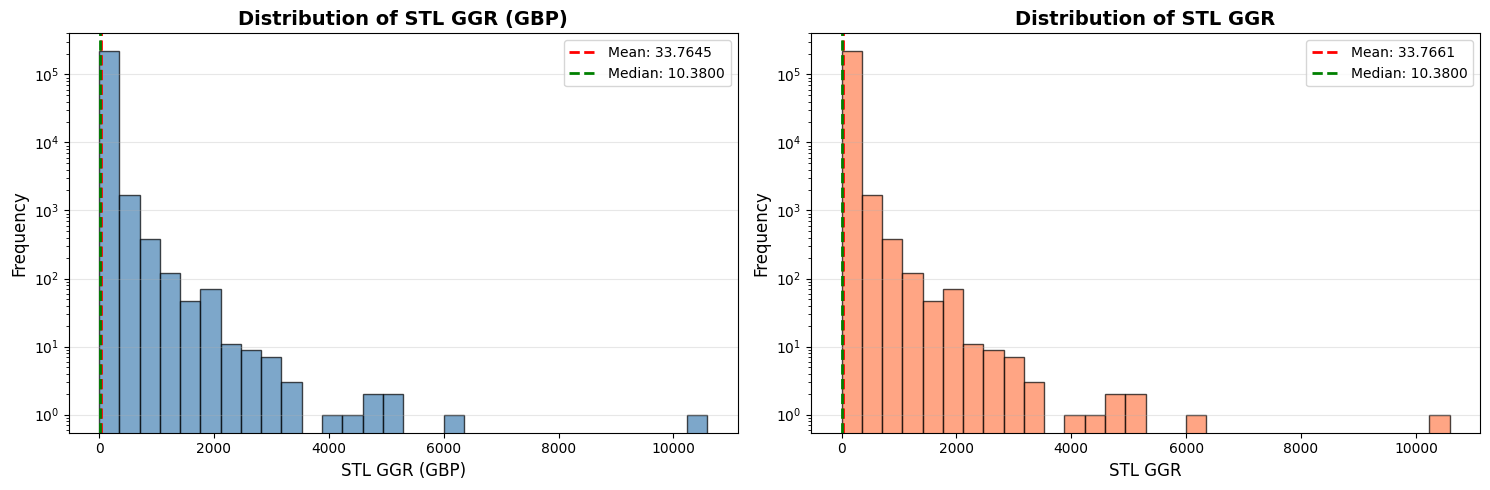

In [53]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# First histogram
ax1.hist(df_raw[df_raw['stl_ggr_gbp'] > 0]['stl_ggr_gbp'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax1.set_xlabel('STL GGR (GBP)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of STL GGR (GBP)', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add statistics
mean_progress = df_raw[df_raw['stl_ggr_gbp'] > 0]['stl_ggr_gbp'].mean()
median_progress = df_raw[df_raw['stl_ggr_gbp'] > 0]['stl_ggr_gbp'].median()
ax1.axvline(mean_progress, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_progress:.4f}')
ax1.axvline(median_progress, color='green', linestyle='--', linewidth=2, label=f'Median: {median_progress:.4f}')
ax1.legend()

# Second histogram
ax2.hist(df_raw[df_raw['stl_ggr'] > 0]['stl_ggr'], bins=30, color='coral', edgecolor='black', alpha=0.7, log=True)
ax2.set_xlabel('STL GGR', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Distribution of STL GGR', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add statistics
mean_fill = df_raw[df_raw['stl_ggr'] > 0]['stl_ggr'].mean()
median_fill = df_raw[df_raw['stl_ggr'] > 0]['stl_ggr'].median()
ax2.axvline(mean_fill, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_fill:.4f}')
ax2.axvline(median_fill, color='green', linestyle='--', linewidth=2, label=f'Median: {median_fill:.4f}')
ax2.legend()

plt.tight_layout()
plt.show()

In [54]:
df_raw['stl_ggr_gbp'] = df_raw['stl_ggr_gbp'].astype(float)

Keeping data points between 0th and 100th percentile (-35,252.3757 - 8,085.6785)
Mean of `stl_ggr_gbp`:
- Original:   3.9794
- Trimmed:    4.0386


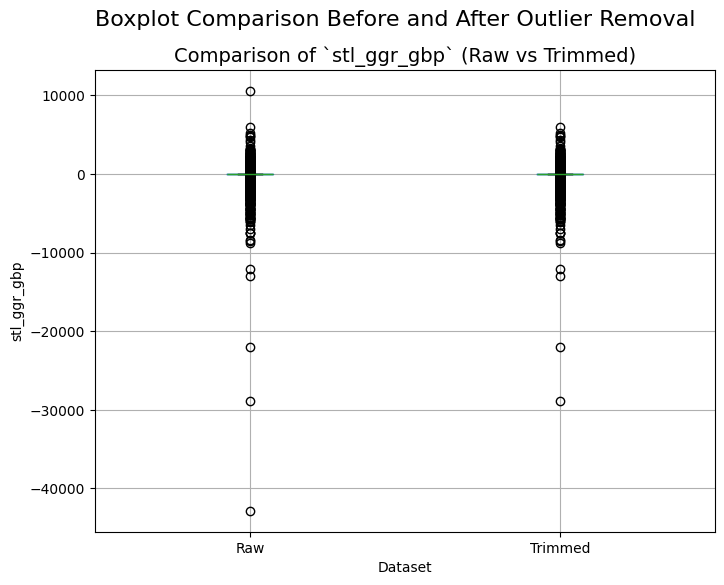

In [55]:
trim_and_draw_boxplot(df_raw, 'stl_ggr_gbp', clipping_range=[0.000001, 0.999999], y_log=False)

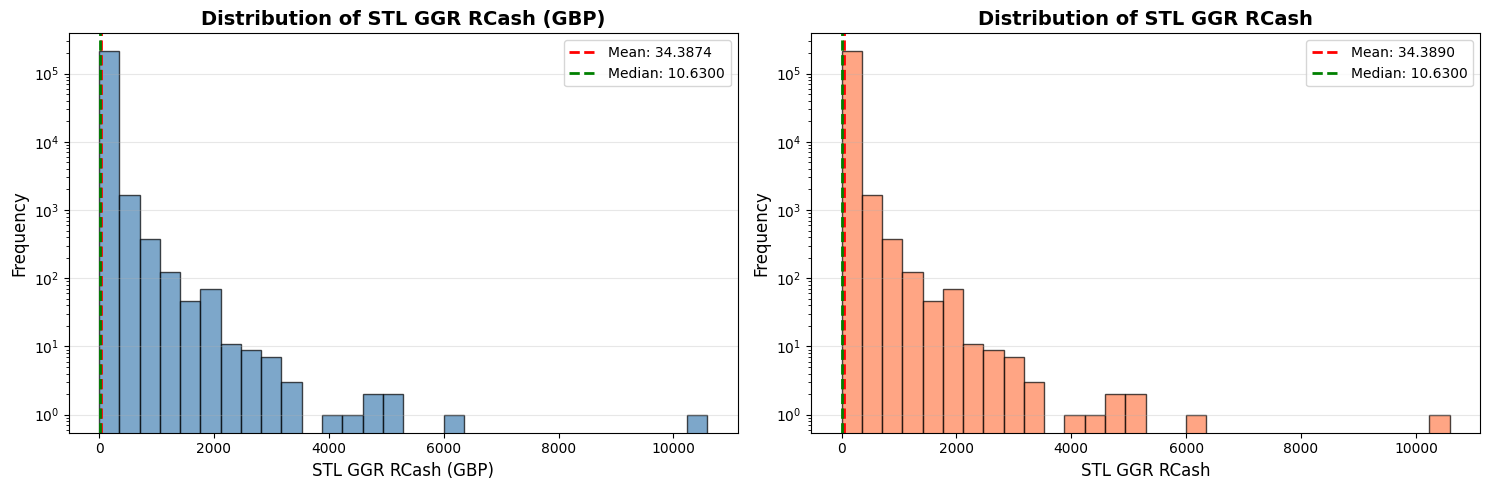

In [56]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# First histogram
ax1.hist(df_raw[df_raw['stl_ggr_gbp_rcash'] > 0]['stl_ggr_gbp_rcash'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax1.set_xlabel('STL GGR RCash (GBP)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of STL GGR RCash (GBP)', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add statistics
mean_progress = df_raw[df_raw['stl_ggr_gbp_rcash'] > 0]['stl_ggr_gbp_rcash'].mean()
median_progress = df_raw[df_raw['stl_ggr_gbp_rcash'] > 0]['stl_ggr_gbp_rcash'].median()
ax1.axvline(mean_progress, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_progress:.4f}')
ax1.axvline(median_progress, color='green', linestyle='--', linewidth=2, label=f'Median: {median_progress:.4f}')
ax1.legend()

# Second histogram
ax2.hist(df_raw[df_raw['stl_ggr_rcash'] > 0]['stl_ggr_rcash'], bins=30, color='coral', edgecolor='black', alpha=0.7, log=True)
ax2.set_xlabel('STL GGR RCash', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Distribution of STL GGR RCash', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add statistics
mean_fill = df_raw[df_raw['stl_ggr_rcash'] > 0]['stl_ggr_rcash'].mean()
median_fill = df_raw[df_raw['stl_ggr_rcash'] > 0]['stl_ggr_rcash'].median()
ax2.axvline(mean_fill, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_fill:.4f}')
ax2.axvline(median_fill, color='green', linestyle='--', linewidth=2, label=f'Median: {median_fill:.4f}')
ax2.legend()

plt.tight_layout()
plt.show()

In [57]:
df_raw['stl_ggr_gbp_rcash'] = df_raw['stl_ggr_gbp_rcash'].astype(float)

Keeping data points between 0th and 100th percentile (-8,619.0854 - 4,485.2931)
Mean of `stl_ggr_gbp_rcash`:
- Original:   3.8056
- Trimmed:    3.9731


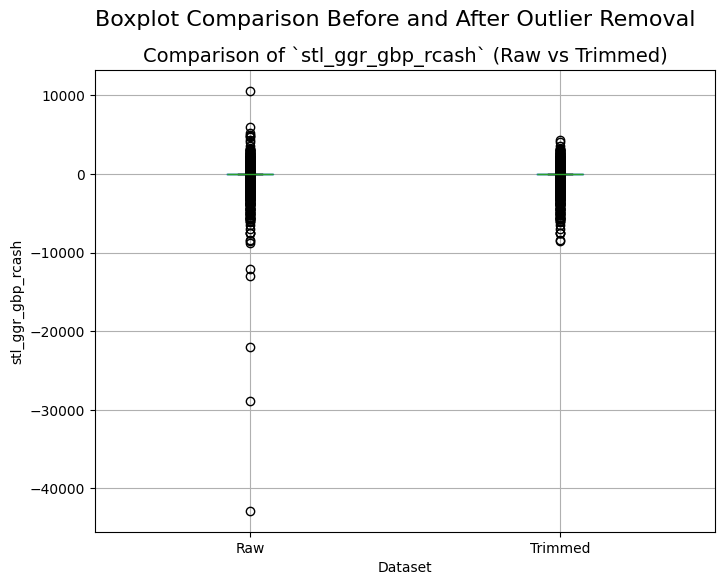

In [58]:
trim_and_draw_boxplot(df_raw, 'stl_ggr_gbp_rcash', clipping_range=[0.00001, 0.99999], y_log=False)

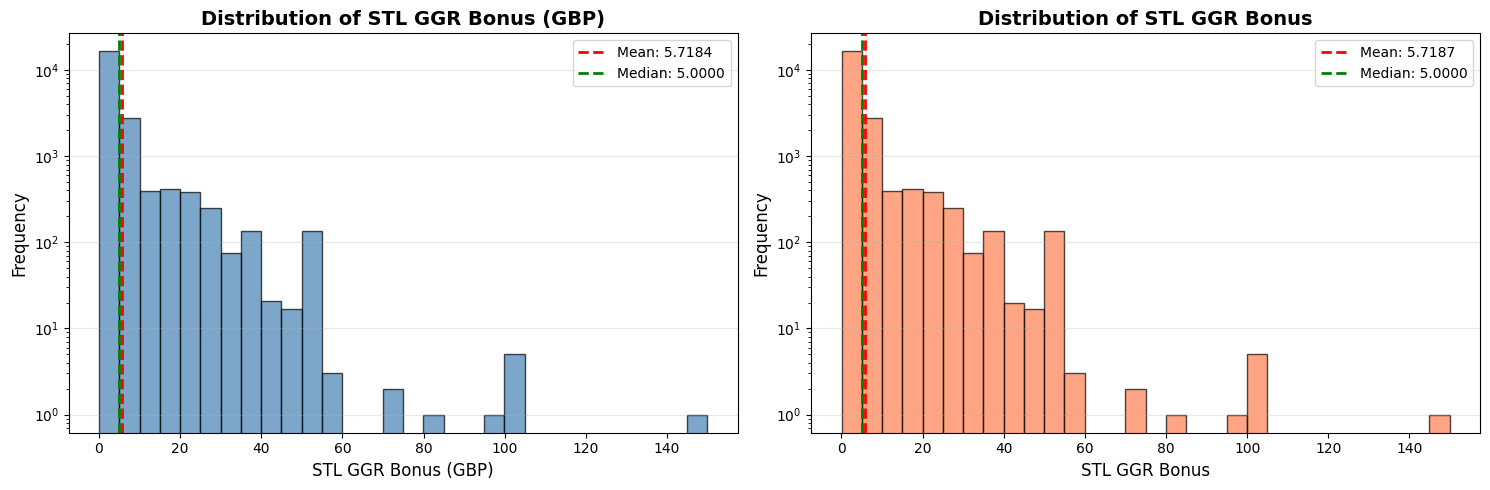

In [59]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# First histogram
ax1.hist(df_raw[df_raw['stl_ggr_gbp_bonus'] > 0]['stl_ggr_gbp_bonus'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax1.set_xlabel('STL GGR Bonus (GBP)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of STL GGR Bonus (GBP)', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add statistics
mean_progress = df_raw[df_raw['stl_ggr_gbp_bonus'] > 0]['stl_ggr_gbp_bonus'].mean()
median_progress = df_raw[df_raw['stl_ggr_gbp_bonus'] > 0]['stl_ggr_gbp_bonus'].median()
ax1.axvline(mean_progress, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_progress:.4f}')
ax1.axvline(median_progress, color='green', linestyle='--', linewidth=2, label=f'Median: {median_progress:.4f}')
ax1.legend()

# Second histogram
ax2.hist(df_raw[df_raw['stl_ggr_bonus'] > 0]['stl_ggr_bonus'], bins=30, color='coral', edgecolor='black', alpha=0.7, log=True)
ax2.set_xlabel('STL GGR Bonus', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Distribution of STL GGR Bonus', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add statistics
mean_fill = df_raw[df_raw['stl_ggr_bonus'] > 0]['stl_ggr_bonus'].mean()
median_fill = df_raw[df_raw['stl_ggr_bonus'] > 0]['stl_ggr_bonus'].median()
ax2.axvline(mean_fill, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_fill:.4f}')
ax2.axvline(median_fill, color='green', linestyle='--', linewidth=2, label=f'Median: {median_fill:.4f}')
ax2.legend()

plt.tight_layout()
plt.show()

In [60]:
df_raw['stl_ggr_gbp_bonus'] = df_raw['stl_ggr_gbp_bonus'].astype(float)

Keeping data points between 0th and 100th percentile (-388.0256 - 98.7628)
Mean of `stl_ggr_gbp_bonus`:
- Original:   0.1738
- Trimmed:    0.1781


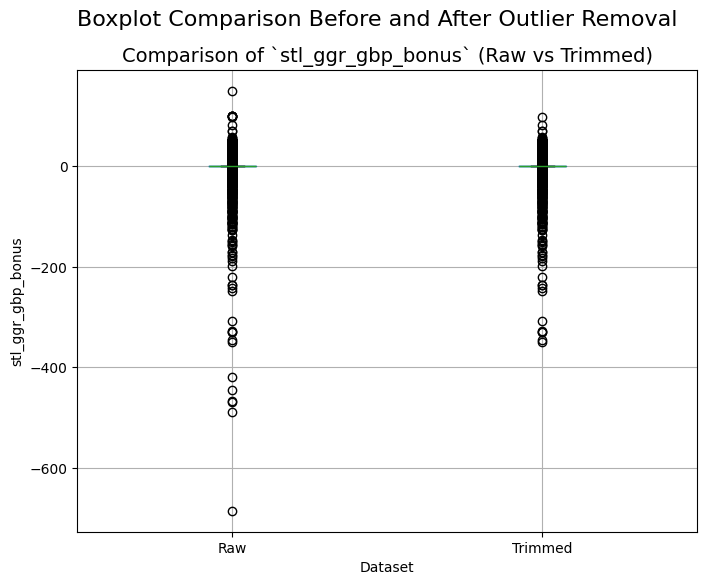

In [61]:
trim_and_draw_boxplot(df_raw, 'stl_ggr_gbp_bonus', clipping_range=[0.00001, 0.99999], y_log=False)

In [62]:
df_raw['stl_betting_duty'].value_counts()

stl_betting_duty
0E-9    545488
Name: count, dtype: int64[pyarrow]

<div class="alert alert-block alert-warning">
    Since <b>stl_betting_duty</b> is not included in the provided dictionary and consistently takes a value of zero, it has been excluded from the training set.
</div>

In [63]:
df_raw['stl_licence_fee'].value_counts()

stl_licence_fee
0E-9    545488
Name: count, dtype: int64[pyarrow]

<div class="alert alert-block alert-warning">
    Since <b>stl_licence_fee</b> is not included in the provided dictionary and consistently takes a value of zero, it has been excluded from the training set.
</div>

In [64]:
df_raw['stl_tax'].value_counts()

stl_tax
0E-9    545488
Name: count, dtype: int64[pyarrow]

<div class="alert alert-block alert-warning">
    Since <b>stl_tax</b> is not included in the provided dictionary and consistently takes a value of zero, it has been excluded from the training set.
</div>

In [65]:
df_raw['stl_partnerfee'].value_counts()

stl_partnerfee
0E-9    545488
Name: count, dtype: int64[pyarrow]

<div class="alert alert-block alert-warning">
    Since <b>stl_partnerfee</b> is not included in the provided dictionary and consistently takes a value of zero, it has been excluded from the training set.
</div>

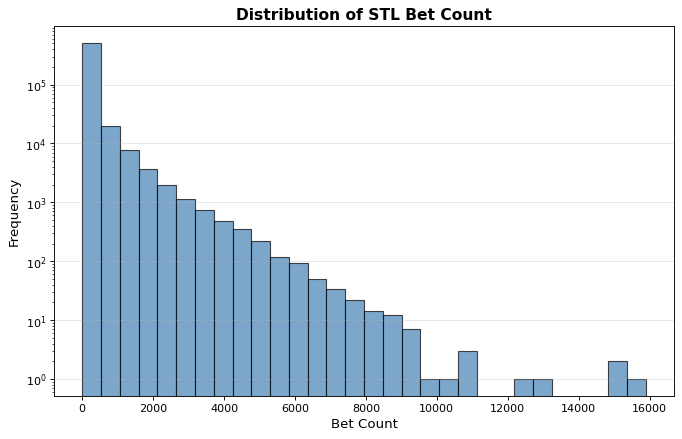

In [66]:
plt.figure(figsize=(10, 6), dpi=80)
ax = plt.gca()

ax.hist(df_raw['stl_betcount'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax.set_xlabel('Bet Count', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of STL Bet Count', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

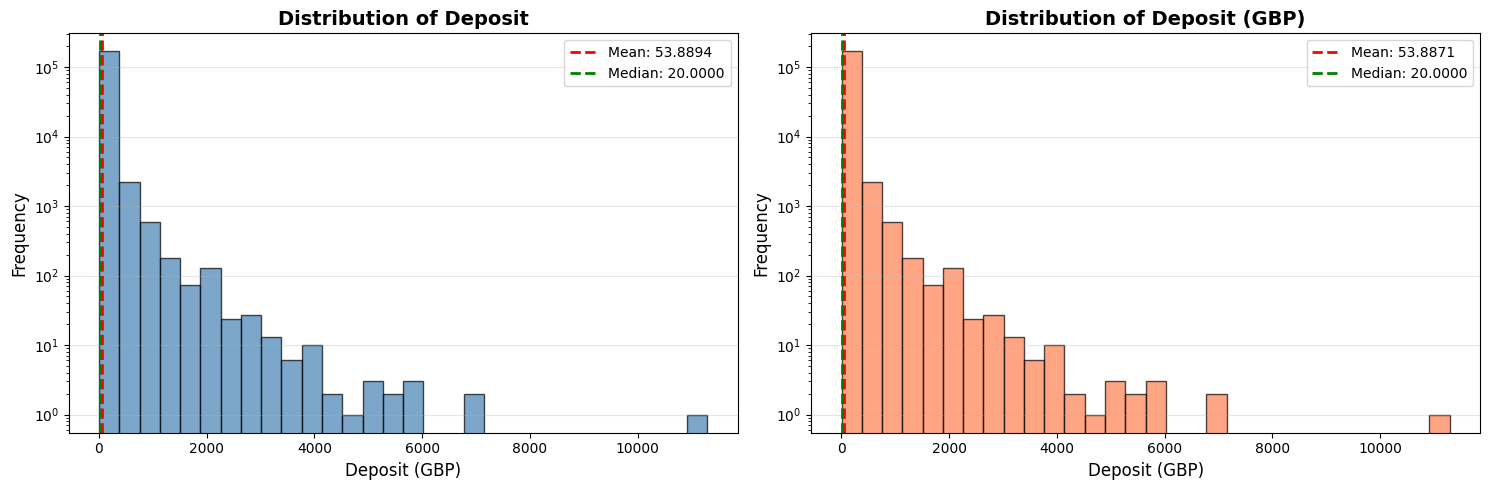

In [67]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# First histogram
ax1.hist(df_raw[df_raw['deposit'] > 0]['deposit'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax1.set_xlabel('Deposit (GBP)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of Deposit', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add statistics
mean_progress = df_raw[df_raw['deposit'] > 0]['deposit'].mean()
median_progress = df_raw[df_raw['deposit'] > 0]['deposit'].median()
ax1.axvline(mean_progress, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_progress:.4f}')
ax1.axvline(median_progress, color='green', linestyle='--', linewidth=2, label=f'Median: {median_progress:.4f}')
ax1.legend()

# Second histogram
ax2.hist(df_raw[df_raw['deposit_gbp'] > 0]['deposit_gbp'], bins=30, color='coral', edgecolor='black', alpha=0.7, log=True)
ax2.set_xlabel('Deposit (GBP)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Distribution of Deposit (GBP)', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add statistics
mean_fill = df_raw[df_raw['deposit_gbp'] > 0]['deposit_gbp'].mean()
median_fill = df_raw[df_raw['deposit_gbp'] > 0]['deposit_gbp'].median()
ax2.axvline(mean_fill, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_fill:.4f}')
ax2.axvline(median_fill, color='green', linestyle='--', linewidth=2, label=f'Median: {median_fill:.4f}')
ax2.legend()

plt.tight_layout()
plt.show()

In [68]:
df_raw['deposit_gbp'] = df_raw['deposit_gbp'].astype(float)

Keeping data points between 0th and 100th percentile (0.0000 - 5,690.7955)
Mean of `deposit_gbp`:
- Original:  16.8552
- Trimmed:   53.6375


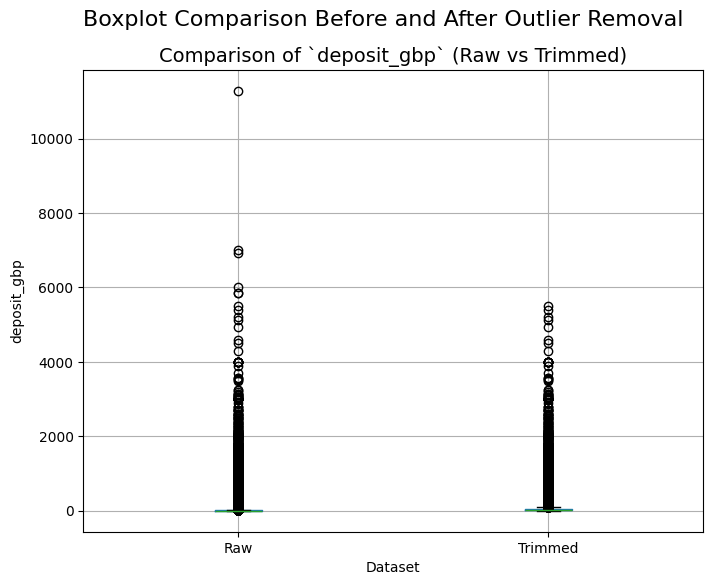

In [69]:
trim_and_draw_boxplot(df_raw, 'deposit_gbp', clipping_range=[0.00001, 0.99999], y_log=False)

<div class="alert alert-block alert-warning">
    As shown in the chart, the presence of an outlier of <b>deposit_gbp</b> has a significant influence on the model’s behavior, and it may be appropriate to consider trimming the data to mitigate its impact.
</div>

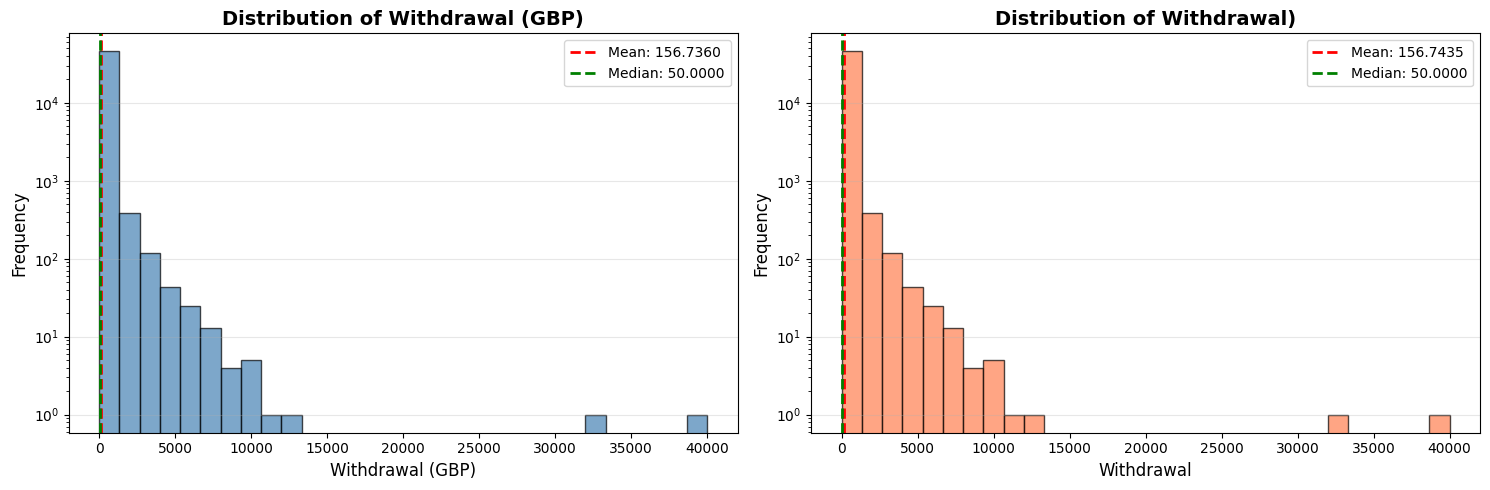

In [70]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# First histogram
ax1.hist(df_raw[df_raw['withdrawal_gbp'] > 0]['withdrawal_gbp'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax1.set_xlabel('Withdrawal (GBP)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of Withdrawal (GBP)', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add statistics
mean_progress = df_raw[df_raw['withdrawal_gbp'] > 0]['withdrawal_gbp'].mean()
median_progress = df_raw[df_raw['withdrawal_gbp'] > 0]['withdrawal_gbp'].median()
ax1.axvline(mean_progress, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_progress:.4f}')
ax1.axvline(median_progress, color='green', linestyle='--', linewidth=2, label=f'Median: {median_progress:.4f}')
ax1.legend()

# Second histogram
ax2.hist(df_raw[df_raw['withdrawal'] > 0]['withdrawal'], bins=30, color='coral', edgecolor='black', alpha=0.7, log=True)
ax2.set_xlabel('Withdrawal', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Distribution of Withdrawal)', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add statistics
mean_fill = df_raw[df_raw['withdrawal'] > 0]['withdrawal'].mean()
median_fill = df_raw[df_raw['withdrawal'] > 0]['withdrawal'].median()
ax2.axvline(mean_fill, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_fill:.4f}')
ax2.axvline(median_fill, color='green', linestyle='--', linewidth=2, label=f'Median: {median_fill:.4f}')
ax2.legend()

plt.tight_layout()
plt.show()

In [71]:
df_raw['withdrawal_gbp'] = df_raw['withdrawal_gbp'].astype(float)

Keeping data points between 0th and 100th percentile (0.0000 - 9,977.2565)
Mean of `withdrawal_gbp`:
- Original:  13.2888
- Trimmed:  154.2045


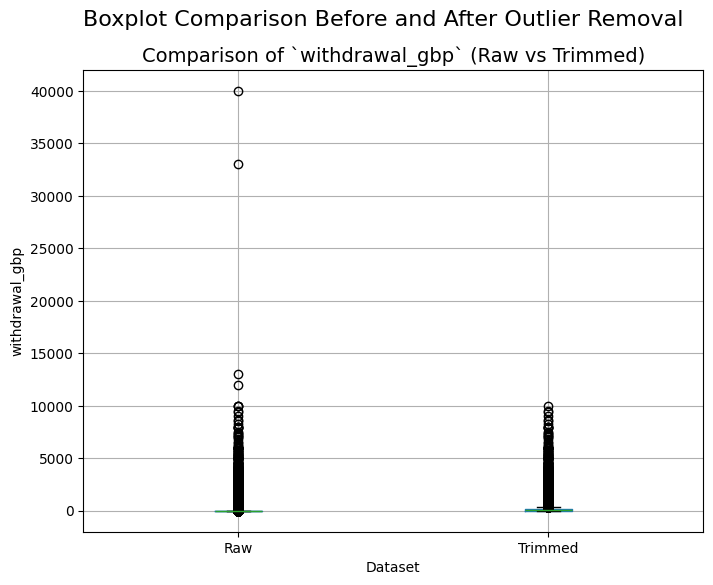

In [72]:
trim_and_draw_boxplot(df_raw, 'withdrawal_gbp', clipping_range=[0.00001, 0.99999], y_log=False)

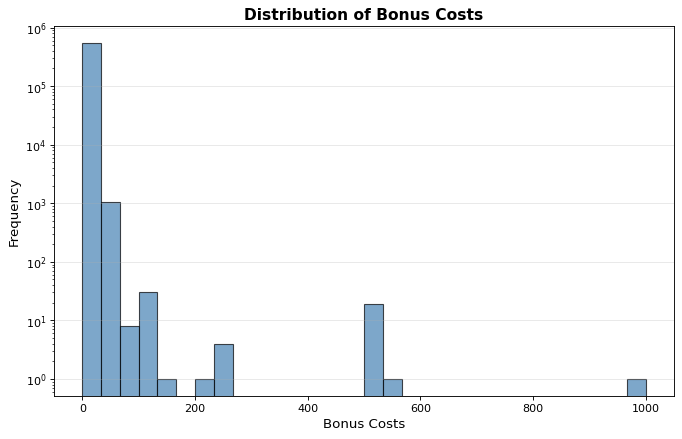

In [73]:
plt.figure(figsize=(10, 6), dpi=80)
ax = plt.gca()

ax.hist(df_raw['bonus_costs'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax.set_xlabel('Bonus Costs', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Bonus Costs', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

In [74]:
df_raw['bonus_costs'] = df_raw['bonus_costs'].astype(float)

Keeping data points between 0th and 100th percentile (-0.0800 - 100.0000)
Mean of `bonus_costs`:
- Original:   0.4446
- Trimmed:    0.4205


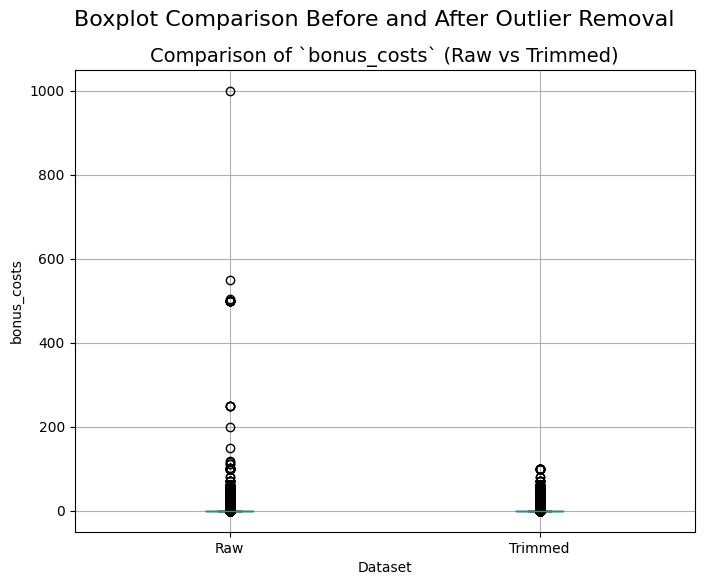

In [75]:
trim_and_draw_boxplot(df_raw, 'bonus_costs', clipping_range=[0, 0.9999], y_log=False)

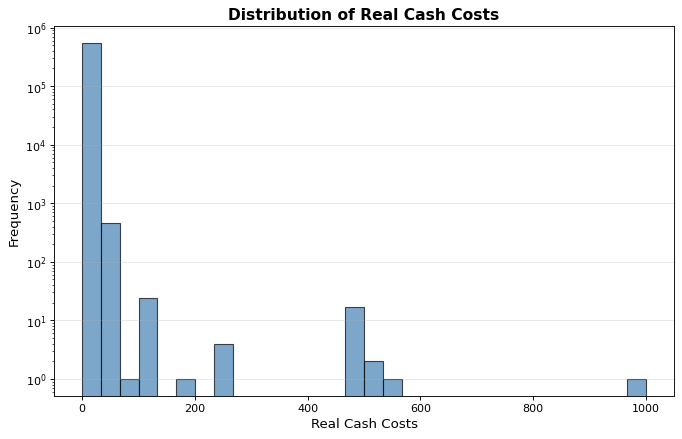

In [76]:
plt.figure(figsize=(10, 6), dpi=80)
ax = plt.gca()

ax.hist(df_raw['realcash_costs'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax.set_xlabel('Real Cash Costs', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Real Cash Costs', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

In [77]:
df_raw['realcash_costs'] = df_raw['realcash_costs'].astype(float)

Keeping data points between 0th and 100th percentile (0.0000 - 60.0000)
Mean of `realcash_costs`:
- Original:   0.1930
- Trimmed:    4.8013


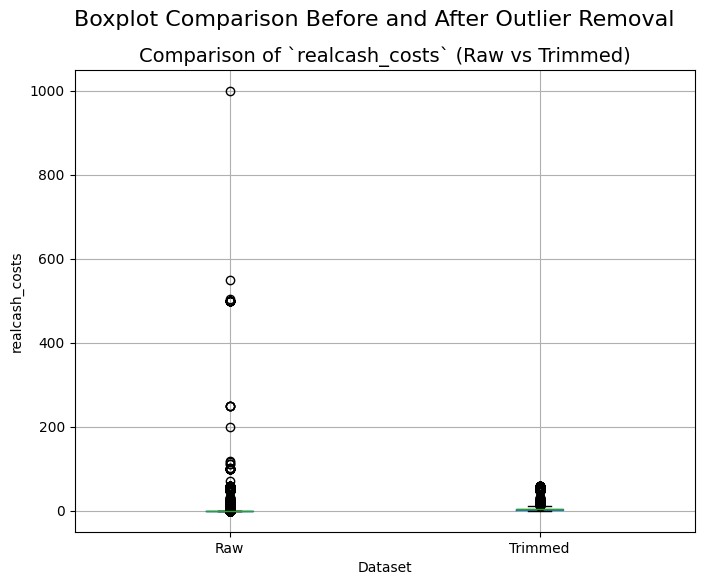

In [78]:
trim_and_draw_boxplot(df_raw, 'realcash_costs', clipping_range=[0, 0.9999], y_log=False)

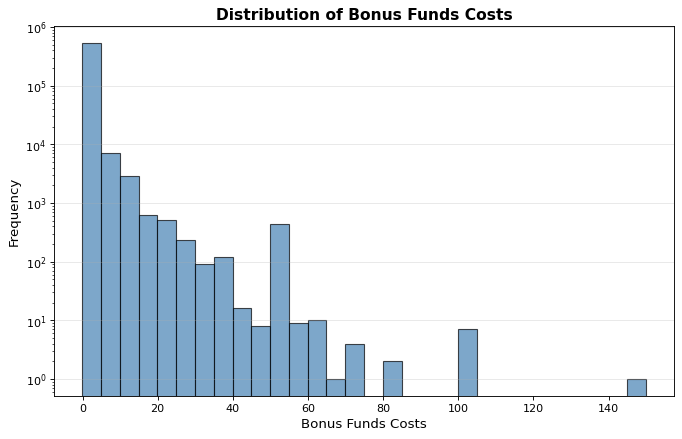

In [79]:
plt.figure(figsize=(10, 6), dpi=80)
ax = plt.gca()

ax.hist(df_raw['bonusfunds_costs'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax.set_xlabel('Bonus Funds Costs', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Bonus Funds Costs', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

In [80]:
df_raw['bonusfunds_costs'] = df_raw['bonusfunds_costs'].astype(float)

Keeping data points between 0th and 100th percentile (-0.0800 - 50.0000)
Mean of `bonusfunds_costs`:
- Original:   0.2517
- Trimmed:    0.2457


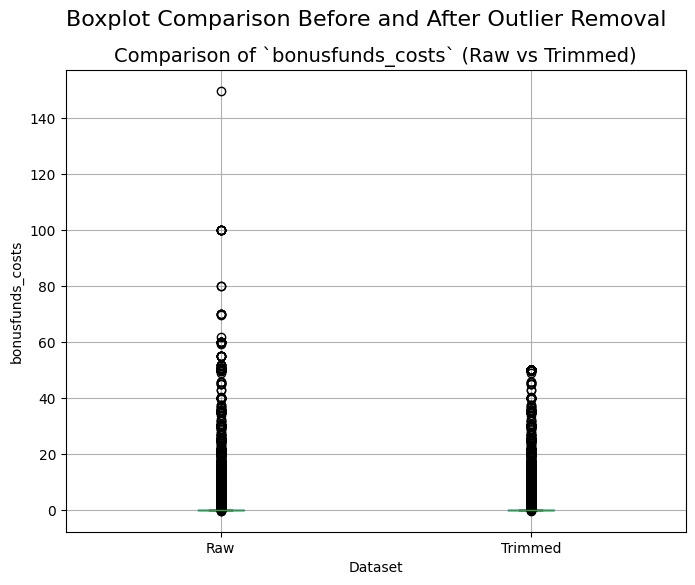

In [81]:
trim_and_draw_boxplot(df_raw, 'bonusfunds_costs', clipping_range=[0, 0.9999], y_log=False)

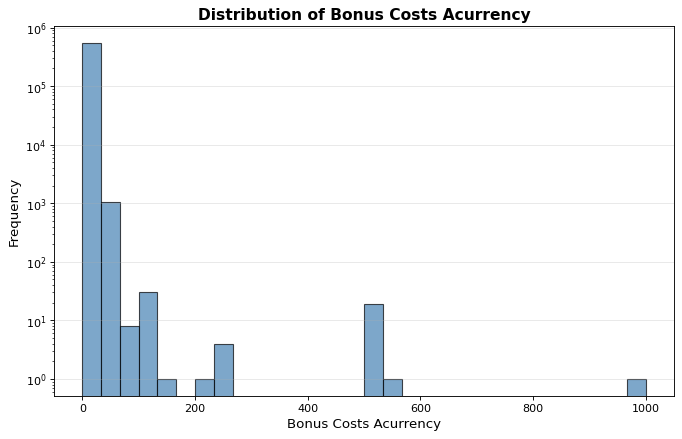

In [82]:
plt.figure(figsize=(10, 6), dpi=80)
ax = plt.gca()

ax.hist(df_raw['bonus_costs_accurrency'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax.set_xlabel('Bonus Costs Acurrency', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Bonus Costs Acurrency', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

In [83]:
df_raw['bonus_costs_accurrency'] = df_raw['bonus_costs_accurrency'].astype(float)

Keeping data points between 0th and 100th percentile (-0.0800 - 100.0000)
Mean of `bonus_costs_accurrency`:
- Original:   0.4447
- Trimmed:    0.4206


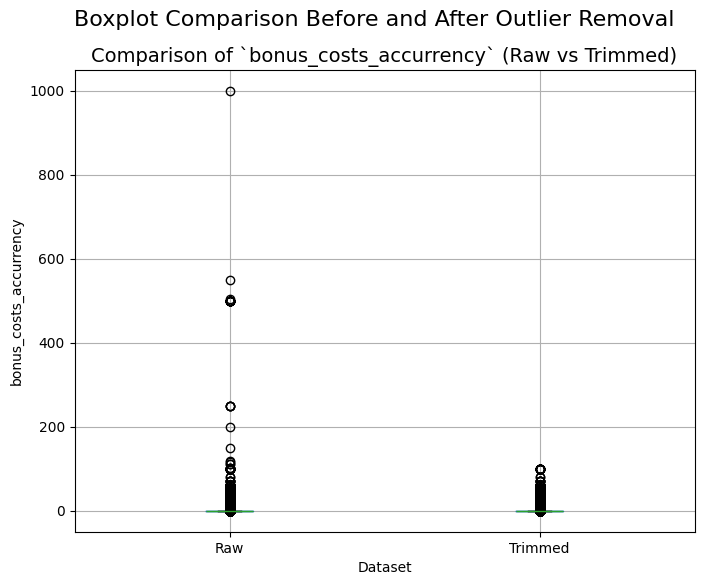

In [84]:
trim_and_draw_boxplot(df_raw, 'bonus_costs_accurrency', clipping_range=[0, 0.9999], y_log=False)

## Account analysis
At present, the retention teams are only able to use inaccurate heuristics for this targeting, notably looking for __customers__ that have been __inactive for 28 days__. This is too late: there is more friction for a returning customer than a still-active one. Moreover, since there are so many false positives, the ‘return’ on retention tactics is lower, pushing the retention teams towards cheaper and less effective measures.

To improve this situation, the Data Science team has been asked to formulate a churn-prediction model to allow more accurate retention targeting whilst the customer remains active (i.e. placing bets). Your challenge is to build a proof-of-concept using the data provided to you.

In [85]:
df_raw['accountid'].nunique()

2000

In [86]:
df_raw['accountid'].unique().tolist()[:5]

[667707849, 667574815, 667338216, 667183293, 667037144]

In [87]:
df_raw_grouped = df_raw[['accountid', 'registration_date']].groupby('accountid').agg({
    'accountid': 'count'
}).rename(columns={'accountid': 'record_count'}).reset_index()

In [88]:
df_raw_grouped.sort_values('record_count', ascending=False, inplace=True)

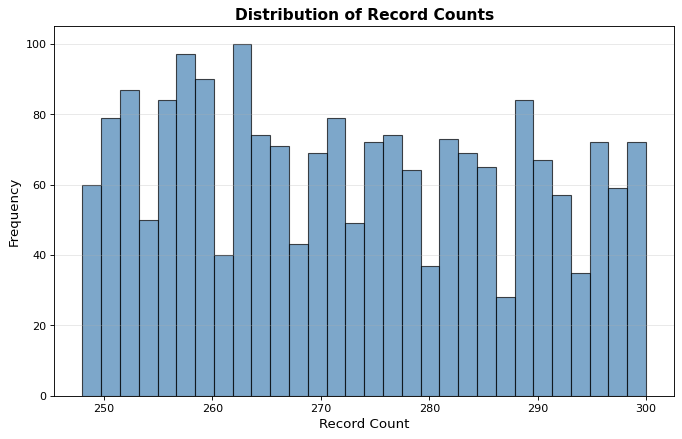

In [89]:
plt.figure(figsize=(10, 6), dpi=80)
ax = plt.gca()

ax.hist(df_raw_grouped['record_count'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=False)
ax.set_xlabel('Record Count', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Record Counts', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

In [90]:
df_raw[df_raw['accountid'] == 667707849][df_raw.columns.tolist()[:15]][:10]

,accountid,registration_date,brandid,agp_brand,reporting_region,market,reg_channel,firstdeposit_createddate,reg_prod,foundation_category,account_tier,ordinalposition,summary_date,category,activity_channel
0,667707849,2021-07-17,2300,Parimatch UK,United Kingdom,Parimatch UK,Mobile,2021-07-17,Sports,NewPlayer,NEW,10,2021-07-19,<NA>,<NA>
103,667707849,2021-07-17,2300,Parimatch UK,United Kingdom,Parimatch UK,Mobile,2021-07-17,Sports,NewPlayer,NEW,10,2021-07-19,eGaming,Not Available
1269,667707849,2021-07-17,2300,Parimatch UK,United Kingdom,Parimatch UK,Mobile,2021-07-17,Sports,NewPlayer,NEW WATCH LIST,11,2021-07-29,eGaming,<NA>
1402,667707849,2021-07-17,2300,Parimatch UK,United Kingdom,Parimatch UK,Mobile,2021-07-17,Sports,NewPlayer,AVERAGE,6,2021-09-11,<NA>,<NA>
1429,667707849,2021-07-17,2300,Parimatch UK,United Kingdom,Parimatch UK,Mobile,2021-07-17,Sports,NewPlayer,AVERAGE,6,2021-09-11,Sports,<NA>
1743,667707849,2021-07-17,2300,Parimatch UK,United Kingdom,Parimatch UK,Mobile,2021-07-17,Sports,NewPlayer,AVERAGE,6,2021-09-11,Sports,Desktop
1777,667707849,2021-07-17,2300,Parimatch UK,United Kingdom,Parimatch UK,Mobile,2021-07-17,Sports,NewPlayer,AVERAGE,6,2021-09-11,eGaming,Not Available
2876,667707849,2021-07-17,2300,Parimatch UK,United Kingdom,Parimatch UK,Mobile,2021-07-17,Sports,NewPlayer,AVERAGE,6,2021-08-26,<NA>,<NA>
2890,667707849,2021-07-17,2300,Parimatch UK,United Kingdom,Parimatch UK,Mobile,2021-07-17,Sports,NewPlayer,AVERAGE,6,2021-08-26,eGaming,<NA>
2975,667707849,2021-07-17,2300,Parimatch UK,United Kingdom,Parimatch UK,Mobile,2021-07-17,Sports,NewPlayer,AVERAGE,6,2021-08-26,eGaming,Not Available


In [91]:
df_raw_summary_date_grouped = df_raw[['accountid', 'summary_date']].groupby('accountid').agg({
    'summary_date': ['count', 'nunique']
}).droplevel(0, axis=1).rename(columns={'accountid': 'record_count'}).reset_index()

In [92]:
df_raw_summary_date_grouped[:5]

,accountid,count,nunique
0,666989420,265,197
1,666989923,273,130
2,666990238,262,113
3,666999616,267,120
4,667005177,289,106


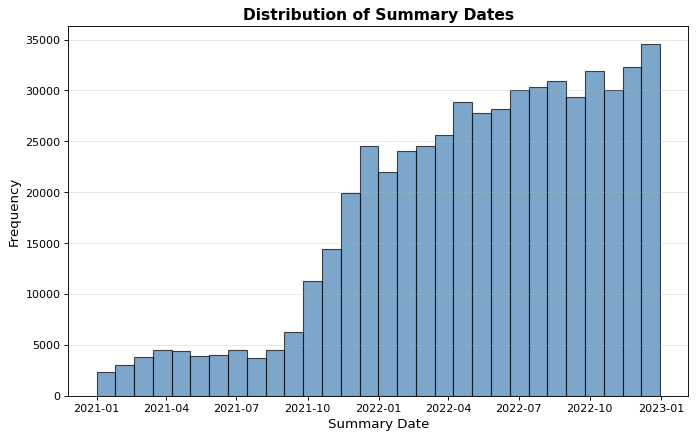

In [93]:
plt.figure(figsize=(10, 6), dpi=80)
ax = plt.gca()

ax.hist(df_raw['summary_date'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=False)
ax.set_xlabel('Summary Date', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Summary Dates', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

Validate that every `summary_date` is represented by either a __minimum of one entry__ or __at least one activity__.

In [94]:
from pandas.api.types import is_numeric_dtype

# Interpret the hypothesis as:
# for each (accountid, summary_date) pair there is either exactly one row,
# or, if there are multiple rows, at least one of them contains activity.

account_col = 'accountid'
date_col = 'summary_date'

analysis_df = df_raw.copy()
analysis_df[date_col] = pd.to_datetime(analysis_df[date_col], errors='coerce')
analysis_df = analysis_df.dropna(subset=[account_col, date_col]).copy()

exclude_numeric_cols = {
    account_col,
    'brandid',
    'ordinalposition'
}
name_hints = (
    'turnover', 'betcount', 'bet_', 'ggr', 'deposit', 'withdrawal',
    'bonus', 'cost', 'fee', 'tax', 'duty', 'stake', 'activity'
)

activity_cols = []
for col in analysis_df.columns:
    if col in exclude_numeric_cols or not is_numeric_dtype(analysis_df[col]):
        continue

    series = analysis_df[col].fillna(0)
    has_non_zero_values = series.ne(0).any()
    looks_like_activity = any(hint in col.lower() for hint in name_hints)

    if has_non_zero_values and looks_like_activity:
        activity_cols.append(col)

if not activity_cols:
    raise ValueError('No numeric activity columns were detected automatically.')

analysis_df['has_activity'] = analysis_df[activity_cols].fillna(0).ne(0).any(axis=1)

pair_summary = (
    analysis_df.groupby([account_col, date_col])
    .agg(
        row_count=('has_activity', 'size'),
        active_row_count=('has_activity', 'sum')
    )
    .reset_index()
)

pair_summary['has_duplicate_rows'] = pair_summary['row_count'] > 1
pair_summary['supports_hypothesis'] = (
    (pair_summary['row_count'] == 1)
    | ((pair_summary['row_count'] > 1) & (pair_summary['active_row_count'] > 0))
)

duplicate_pairs = pair_summary[pair_summary['has_duplicate_rows']].copy()
violations = pair_summary[~pair_summary['supports_hypothesis']].copy()

print(f"Detected {len(activity_cols)} activity columns.")
print(f"Unique accounts: {analysis_df[account_col].nunique():,}")
print(f"Unique (accountid, summary_date) pairs: {len(pair_summary):,}")
print(f"Pairs with duplicate rows: {len(duplicate_pairs):,}")
print(f"Pairs violating the hypothesis: {len(violations):,}")

if violations.empty:
    print('\nResult: the hypothesis holds under this interpretation.')
else:
    print('\nResult: the hypothesis does not hold under this interpretation.')
    display(
        violations
        .sort_values(['row_count', 'active_row_count'], ascending=[False, False])
        .head(20)
    )

Detected 29 activity columns.
Unique accounts: 2,000
Unique (accountid, summary_date) pairs: 248,001
Pairs with duplicate rows: 196,973
Pairs violating the hypothesis: 0

Result: the hypothesis holds under this interpretation.


In [95]:
df_raw[df_raw['accountid'] == 667707849][df_raw.columns.tolist()[:15]][['accountid', 'summary_date', 'ordinalposition', 'account_tier', 'category', 'activity_channel']][:25]

,accountid,summary_date,ordinalposition,account_tier,category,activity_channel
0,667707849,2021-07-19,10,NEW,<NA>,<NA>
103,667707849,2021-07-19,10,NEW,eGaming,Not Available
1269,667707849,2021-07-29,11,NEW WATCH LIST,eGaming,<NA>
1402,667707849,2021-09-11,6,AVERAGE,<NA>,<NA>
1429,667707849,2021-09-11,6,AVERAGE,Sports,<NA>
1743,667707849,2021-09-11,6,AVERAGE,Sports,Desktop
1777,667707849,2021-09-11,6,AVERAGE,eGaming,Not Available
2876,667707849,2021-08-26,6,AVERAGE,<NA>,<NA>
2890,667707849,2021-08-26,6,AVERAGE,eGaming,<NA>
2975,667707849,2021-08-26,6,AVERAGE,eGaming,Not Available


In [96]:
df_summary_dates = df_raw[['accountid', 'summary_date']].sort_values(['accountid', 'summary_date'], ascending=True).copy()
df_summary_dates['summary_date'] = pd.to_datetime(df_summary_dates['summary_date'], errors='coerce')
df_summary_dates['summary_date_difference'] = (
    df_summary_dates.groupby('accountid')['summary_date']
    .diff()
    .dt.days
)

In [97]:
# Longest gap between summary dates for the same account
df_summary_dates[df_summary_dates['summary_date_difference'] == 450]

,accountid,summary_date,summary_date_difference
66946,667172357,2022-11-24,450.0


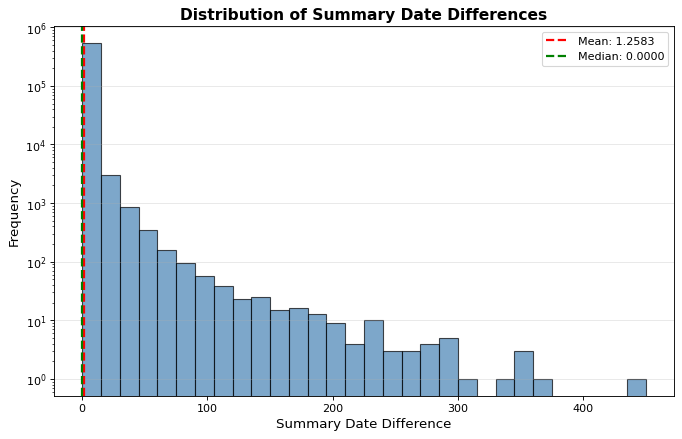

In [98]:
plt.figure(figsize=(10, 6), dpi=80)
ax = plt.gca()

ax.hist(df_summary_dates['summary_date_difference'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax.set_xlabel('Summary Date Difference', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Summary Date Differences', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

mean_progress = df_summary_dates['summary_date_difference'].mean()
median_progress = df_summary_dates['summary_date_difference'].median()
ax.axvline(mean_progress, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_progress:.4f}')
ax.axvline(median_progress, color='green', linestyle='--', linewidth=2, label=f'Median: {median_progress:.4f}')
ax.legend()

This might be misleading as usually more than one entry is present in the set per category/secondary_category etc.

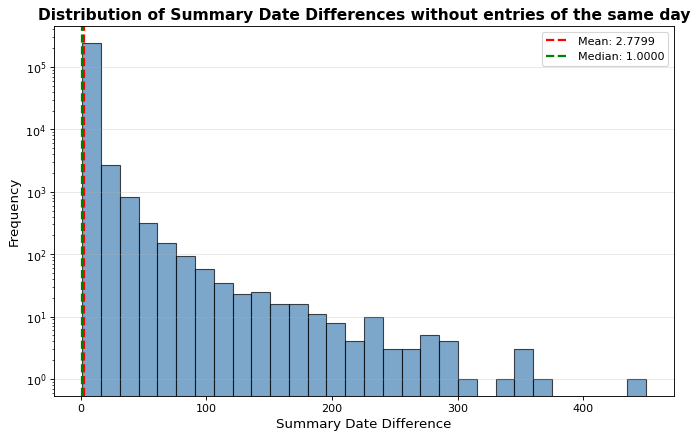

In [99]:
plt.figure(figsize=(10, 6), dpi=80)
ax = plt.gca()

ax.hist(df_summary_dates[df_summary_dates['summary_date_difference'] > 0]['summary_date_difference'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax.set_xlabel('Summary Date Difference', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Summary Date Differences without entries of the same day', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

mean_progress = df_summary_dates[df_summary_dates['summary_date_difference'] > 0]['summary_date_difference'].mean()
median_progress = df_summary_dates[df_summary_dates['summary_date_difference'] > 0]['summary_date_difference'].median()
ax.axvline(mean_progress, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_progress:.4f}')
ax.axvline(median_progress, color='green', linestyle='--', linewidth=2, label=f'Median: {median_progress:.4f}')
ax.legend()

In [100]:
df_raw[['ordinalposition', 'account_tier']].value_counts(dropna=False)    

ordinalposition  account_tier  
3                VALUED            261129
2                Premium           137744
4                MEDIUM             33050
10               NEW                25800
9                WINNERS            20486
6                AVERAGE            18353
7                LOW                17835
5                ABOVE AVERAGE      12601
8                LOWEST              9953
12               NO VALUE            4023
11               NEW WATCH LIST      2722
13               NON DEPOSITOR       1727
14               CLOSED                65
Name: count, dtype: int64

`ordinalpostition` is indeed linked with `account_tier`

### Activity fields

In [101]:
df_raw.columns

Index(['accountid', 'registration_date', 'brandid', 'agp_brand',
       'reporting_region', 'market', 'reg_channel', 'firstdeposit_createddate',
       'reg_prod', 'foundation_category', 'account_tier', 'ordinalposition',
       'summary_date', 'category', 'activity_channel', 'secondary_product',
       'bet_type', 'productgroup', 'plc_turnover_gbp', 'plc_turnover',
       'plc_turnover_gbp_rcash', 'plc_turnover_rcash',
       'plc_turnover_gbp_bonus', 'plc_turnover_bonus', 'plc_betcount',
       'stl_turnover_gbp', 'stl_turnover', 'stl_turnover_gbp_rcash',
       'stl_turnover_rcash', 'stl_turnover_gbp_bonus', 'stl_turnover_bonus',
       'stl_ggr_gbp', 'stl_ggr', 'stl_ggr_gbp_rcash', 'stl_ggr_rcash',
       'stl_ggr_gbp_bonus', 'stl_ggr_bonus', 'stl_betting_duty',
       'stl_licence_fee', 'stl_tax', 'stl_partnerfee', 'stl_betcount',
       'deposit', 'deposit_gbp', 'withdrawal', 'withdrawal_gbp', 'bonus_costs',
       'realcash_costs', 'bonusfunds_costs', 'bonus_costs_accurrency',
 

In [102]:
activity_columns = [
       #'bet_type', 'productgroup',

       # Placed stakes
       # Including only columns reported in GBP to maintain consistency and comparability.
       'plc_betcount', 'plc_turnover_gbp', 'plc_turnover_gbp_rcash', 'plc_turnover_gbp_bonus', 
       
       # Settled bets
       'stl_betcount', 'stl_turnover_gbp', 'stl_turnover_gbp_rcash', 'stl_turnover_gbp_bonus',

       # Settled Gross Gaming Revenue
       'stl_ggr_gbp', 'stl_ggr_gbp_rcash', 'stl_ggr_gbp_bonus',
       
       # deposit/withdrawal
       'deposit_gbp', 'withdrawal_gbp',
       
       # These variables are not listed in the provided documentation and the `costs` word suggests that it is either calculated or not related to the customers's behaviour
       #'bonus_costs', 'realcash_costs', 'bonusfunds_costs', 'bonus_costs_accurrency', 'bonusfunds_costs_accurrency' 
]

In [103]:
df_raw[df_raw['accountid'] == 667172357][['accountid', 'summary_date', 'bet_type',
       'category', 'secondary_product', 
       'plc_betcount', 'stl_betcount']].sort_values('summary_date', ascending=False).head(20)

,accountid,summary_date,bet_type,category,secondary_product,plc_betcount,stl_betcount
412620,667172357,2022-12-29,<NA>,<NA>,<NA>,0.0,0E-9
412669,667172357,2022-12-29,Single,Sports,Horse Racing,6.0,6.000000000
412672,667172357,2022-12-29,Combi,Sports,Horse Racing,2.0,2.000000000
526241,667172357,2022-12-19,<NA>,<NA>,<NA>,0.0,0E-9
526550,667172357,2022-12-19,Single,Sports,Horse Racing,1.0,1.000000000
202435,667172357,2022-12-10,<NA>,<NA>,<NA>,0.0,0E-9
202586,667172357,2022-12-10,Single,Sports,Football,2.0,2.000000000
70751,667172357,2022-11-27,Single,Sports,Football,1.0,1.000000000
486989,667172357,2022-11-26,<NA>,<NA>,<NA>,0.0,0E-9
487102,667172357,2022-11-26,Single,Sports,Football,2.0,2.000000000


In [104]:
df_raw[df_raw['accountid'] == 667172357][list(set(list(['summary_date']) + list(df_raw.columns[10:20])))].sort_values('summary_date', ascending=True)[-10:]

,secondary_product,productgroup,account_tier,plc_turnover_gbp,bet_type,ordinalposition,summary_date,category,activity_channel,plc_turnover
487102,Football,Sportsbook,LOWEST,15.00,Single,8,2022-11-26,Sports,Mobile,15.000000000
487113,Horse Racing,Sportsbook,LOWEST,10.00,Single,8,2022-11-26,Sports,Mobile,10.000000000
70751,Football,Sportsbook,LOWEST,5.00,Single,8,2022-11-27,Sports,Mobile,5.000000000
202435,<NA>,<NA>,LOWEST,0.00,<NA>,8,2022-12-10,<NA>,<NA>,0E-9
202586,Football,Sportsbook,LOWEST,20.00,Single,8,2022-12-10,Sports,Mobile,20.000000000
526241,<NA>,<NA>,LOW,0.00,<NA>,7,2022-12-19,<NA>,<NA>,0E-9
526550,Horse Racing,Sportsbook,LOW,10.00,Single,7,2022-12-19,Sports,Mobile,10.000000000
412620,<NA>,<NA>,LOW,0.00,<NA>,7,2022-12-29,<NA>,<NA>,0E-9
412669,Horse Racing,Sportsbook,LOW,156.04,Single,7,2022-12-29,Sports,Mobile,156.040000000
412672,Horse Racing,Sportsbook,LOW,50.00,Combi,7,2022-12-29,Sports,Mobile,50.000000000


In [105]:
df_raw[df_raw['accountid'] == 667172357][['accountid', 'summary_date',
       'bet_type', 'category', 'secondary_product',
       'plc_turnover', 'plc_betcount', 'stl_turnover', 'stl_betcount', 'deposit', 'deposit_gbp',
       'withdrawal', 'withdrawal_gbp']].sort_values('summary_date', ascending=True)[-20:]

,accountid,summary_date,bet_type,category,secondary_product,plc_turnover,plc_betcount,stl_turnover,stl_betcount,deposit,deposit_gbp,withdrawal,withdrawal_gbp
110328,667172357,2021-06-07,Combi,Sports,Football,0E-9,0.0,5.000000000,1.000000000,0E-9,0.0,0E-9,0.0
203470,667172357,2021-06-28,Combi,Sports,Football,5.000000000,1.0,5.000000000,1.000000000,0E-9,0.0,0E-9,0.0
203588,667172357,2021-06-28,<NA>,<NA>,<NA>,0E-9,0.0,0E-9,0E-9,5.000000000,5.0,0E-9,0.0
83490,667172357,2021-07-12,Single,Sports,Football,0E-9,0.0,20.000000000,1.000000000,0E-9,0.0,0E-9,0.0
7634,667172357,2021-08-31,Combi,Sports,Horse Racing,5.000000000,1.0,5.000000000,1.000000000,0E-9,0.0,0E-9,0.0
7670,667172357,2021-08-31,<NA>,<NA>,<NA>,0E-9,0.0,0E-9,0E-9,5.000000000,5.0,0E-9,0.0
66946,667172357,2022-11-24,<NA>,<NA>,<NA>,0E-9,0.0,0E-9,0E-9,10.000000000,10.0,0E-9,0.0
66954,667172357,2022-11-24,Combi,Sports,Football,10.000000000,1.0,0E-9,0E-9,0E-9,0.0,0E-9,0.0
503774,667172357,2022-11-25,Combi,Sports,Football,0E-9,0.0,10.000000000,1.000000000,0E-9,0.0,0E-9,0.0
486989,667172357,2022-11-26,<NA>,<NA>,<NA>,0E-9,0.0,0E-9,0E-9,30.000000000,30.0,0E-9,0.0


## Last activity check

In [106]:
for i in tqdm(df_raw['accountid'].unique()):
    account_data = df_raw[
        (df_raw['accountid'] == i) &
        (df_raw['bet_type'].notnull()) &
        (df_raw['category'].notnull()) &
        (df_raw['secondary_product'].notnull())
    ][list(['summary_date']) + activity_columns].sort_values('summary_date', ascending=False)
    if len(account_data) <= 1:
        continue

    last_unchanged_date = None
    for j in range(len(account_data) - 1):
        if (account_data.iloc[j] == account_data.iloc[j + 1]).sum() == len(activity_columns):
            if last_unchanged_date is None:
                last_unchanged_date = account_data.iloc[j]['summary_date']

    if last_unchanged_date is not None:
        df_raw.loc[df_raw['accountid'] == i, 'last_unchanged_date'] = last_unchanged_date

100%|██████████| 2000/2000 [00:54<00:00, 36.50it/s]


In [107]:
df_raw[['accountid', 'summary_date', 'last_unchanged_date'] + activity_columns].sort_values(['accountid', 'summary_date'], ascending=True)[50:100]

,accountid,summary_date,last_unchanged_date,plc_betcount,plc_turnover_gbp,plc_turnover_gbp_rcash,plc_turnover_gbp_bonus,stl_betcount,stl_turnover_gbp,stl_turnover_gbp_rcash,stl_turnover_gbp_bonus,stl_ggr_gbp,stl_ggr_gbp_rcash,stl_ggr_gbp_bonus,deposit_gbp,withdrawal_gbp
358710,666989420,2021-04-09,2022-08-07,1.0,0.80,0.80,0.0,2.000000000,1.60,1.60,0.0,-0.91,-0.91,0.0,0.0,0.0
358826,666989420,2021-04-09,2022-08-07,0.0,0.00,0.00,0.0,1.000000000,0.75,0.75,0.0,0.75,0.75,0.0,0.0,0.0
194800,666989420,2021-04-10,2022-08-07,1.0,0.80,0.80,0.0,1.000000000,0.80,0.80,0.0,0.80,0.80,0.0,0.0,0.0
194808,666989420,2021-04-10,2022-08-07,0.0,0.00,0.00,0.0,1.000000000,0.70,0.70,0.0,0.70,0.70,0.0,0.0,0.0
206695,666989420,2021-04-11,2022-08-07,0.0,0.00,0.00,0.0,0E-9,0.00,0.00,0.0,0.00,0.00,0.0,0.0,10.0
206700,666989420,2021-04-11,2022-08-07,0.0,0.00,0.00,0.0,1.000000000,0.80,0.80,0.0,0.80,0.80,0.0,0.0,0.0
17134,666989420,2021-04-26,2022-08-07,1.0,0.50,0.50,0.0,0E-9,0.00,0.00,0.0,0.00,0.00,0.0,0.0,0.0
69514,666989420,2021-04-27,2022-08-07,0.0,0.00,0.00,0.0,1.000000000,0.50,0.50,0.0,0.50,0.50,0.0,0.0,0.0
262505,666989420,2021-05-01,2022-08-07,3.0,0.75,0.75,0.0,3.000000000,0.75,0.75,0.0,0.31,0.31,0.0,0.0,0.0
375129,666989420,2021-05-03,2022-08-07,1.0,1.00,1.00,0.0,1.000000000,1.00,1.00,0.0,-0.62,-0.62,0.0,0.0,0.0


### Interpretation of deposit/withdrawal columns

In [108]:
df_grouped = df_raw[['accountid', 'deposit']].groupby('deposit').agg({'accountid': 'count'}).sort_values('deposit', ascending=False).sort_values('accountid', ascending=False).rename(columns={'accountid': 'frequency'}).reset_index()

__Assumption__: both the deposit and withdrawal columns contain the amount of money deposited and withdrawn and not the balance

In [109]:
df_grouped['cum_frequency'] = df_grouped['frequency'].cumsum()
df_grouped['cum_percentage'] = df_grouped['cum_frequency'] / df_grouped['frequency'].sum() * 100

In [110]:
df_grouped[df_grouped['deposit'] > 0][0:25]

,deposit,frequency,cum_frequency,cum_percentage
1,10.000000000,43710,418576,76.734227
2,20.000000000,30450,449026,82.316385
3,5.000000000,12072,461098,84.529449
4,50.000000000,11350,472448,86.610155
5,30.000000000,7555,480003,87.995153
6,40.000000000,6470,486473,89.181247
7,15.000000000,5331,491804,90.158537
8,100.000000000,4513,496317,90.98587
9,25.000000000,2782,499099,91.495872
10,60.000000000,2690,501789,91.989008


- The first 16 entries (93.42%) are divisible by 5
- The first 163 entries (97.96%) are integer

It is highly improbable that the majority of the customers' balance is integer number so it is indeed the amount of deposited/withdrawn money.

### Gap between activities

In [111]:
account_summary_date_diff = (
    df_raw.groupby('accountid', as_index=False)['summary_date']
    .max()
    .assign(
        summary_date=lambda df: pd.to_datetime(df['summary_date']),
        days_till_2022_12_31=lambda df: (
            pd.Timestamp('2022-12-31') - df['summary_date']
        ).dt.days,
    )
)

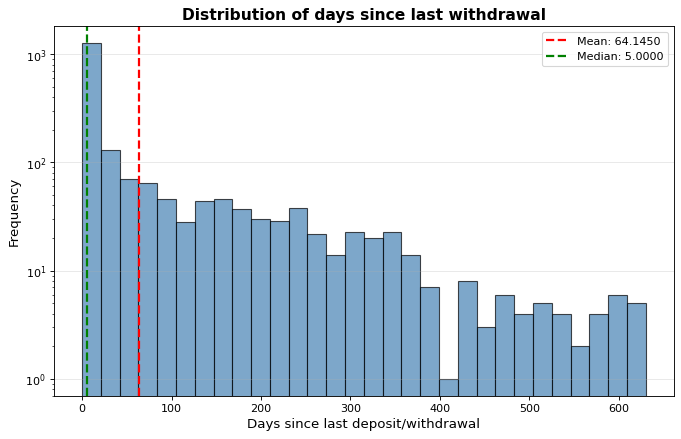

In [112]:
plt.figure(figsize=(10, 6), dpi=80)
ax = plt.gca()

ax.hist(account_summary_date_diff['days_till_2022_12_31'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax.set_xlabel('Days since last deposit/withdrawal', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of days since last withdrawal', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

mean_progress = account_summary_date_diff['days_till_2022_12_31'].mean()
median_progress = account_summary_date_diff['days_till_2022_12_31'].median()
ax.axvline(mean_progress, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_progress:.4f}')
ax.axvline(median_progress, color='green', linestyle='--', linewidth=2, label=f'Median: {median_progress:.4f}')
ax.legend()

#### Random checks

In [113]:
for i in df_raw['accountid'].sample(5):
    print("{:}, days until 2022-12-31: {:}".format(
        i,
        account_summary_date_diff[account_summary_date_diff['accountid'] == i].iloc[0]['days_till_2022_12_31']
    ))

    display(
        df_raw[
            df_raw['accountid'] == i
        ].sort_values(['accountid', 'summary_date'], ascending=True)[['accountid', 'summary_date']][-3:]
    )

668122852, days until 2022-12-31: 0


,accountid,summary_date
299421,668122852,2022-12-28
300063,668122852,2022-12-28
289392,668122852,2022-12-31


668180790, days until 2022-12-31: 6


,accountid,summary_date
480101,668180790,2022-12-18
488513,668180790,2022-12-25
488884,668180790,2022-12-25


667944498, days until 2022-12-31: 0


,accountid,summary_date
271461,667944498,2022-12-30
288670,667944498,2022-12-31
289079,667944498,2022-12-31


667857161, days until 2022-12-31: 41


,accountid,summary_date
404710,667857161,2022-09-23
405218,667857161,2022-09-23
77178,667857161,2022-11-20


667048699, days until 2022-12-31: 147


,accountid,summary_date
345947,667048699,2022-08-06
345967,667048699,2022-08-06
345968,667048699,2022-08-06


#### Charts

In [114]:
account_summary_date_diff.sort_values('days_till_2022_12_31', ascending=True, inplace=True)

In [115]:
account_summary_date_diff['cum_elapsed_days_frequency'] = account_summary_date_diff['days_till_2022_12_31'].cumsum()
account_summary_date_diff['cum_elapsed_days_percentage'] = account_summary_date_diff['cum_elapsed_days_frequency'] / account_summary_date_diff['cum_elapsed_days_frequency'].sum() * 100

In [116]:
account_summary_date_diff['account_frequency'] = 1/account_summary_date_diff.shape[0]
account_summary_date_diff['cum_account_percentage'] = account_summary_date_diff['account_frequency'].cumsum() * 100

In [117]:
account_summary_date_diff[['cum_elapsed_days_percentage', 'cum_account_percentage']][:5]

,cum_elapsed_days_percentage,cum_account_percentage
1999,0.0,0.05
803,0.0,0.10
804,0.0,0.15
805,0.0,0.20
806,0.0,0.25


In [118]:
account_summary_date_diff.columns

Index(['accountid', 'summary_date', 'days_till_2022_12_31',
       'cum_elapsed_days_frequency', 'cum_elapsed_days_percentage',
       'account_frequency', 'cum_account_percentage'],
      dtype='str')

In [119]:
account_summary_date_diff_plot = account_summary_date_diff[['account_frequency', 'days_till_2022_12_31']].sort_values('days_till_2022_12_31', ascending=True)
account_summary_date_diff_plot['cum_account_frequency'] = account_summary_date_diff_plot['account_frequency'].cumsum()

In [120]:
account_summary_date_diff_plot[['account_frequency', 'cum_account_frequency', 'days_till_2022_12_31']][:5]

,account_frequency,cum_account_frequency,days_till_2022_12_31
1999,0.0005,0.0005,0
1226,0.0005,0.0010,0
1224,0.0005,0.0015,0
1223,0.0005,0.0020,0
1216,0.0005,0.0025,0


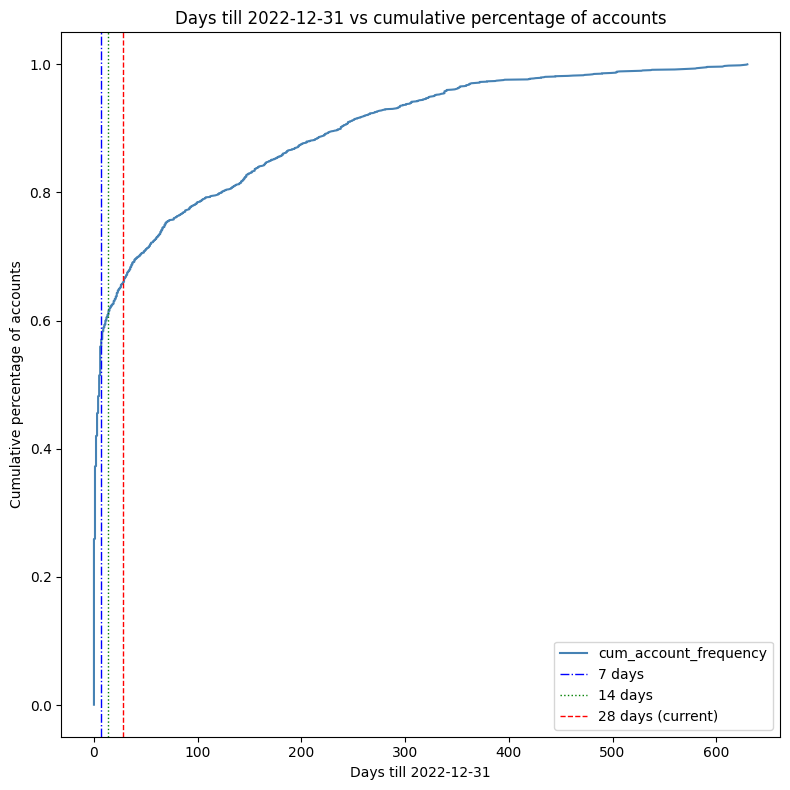

In [121]:
ax = account_summary_date_diff_plot.plot(
    x='days_till_2022_12_31',
    y='cum_account_frequency',
    figsize=(8, 8),
    color='steelblue'
)

ax.set_xlabel('Days till 2022-12-31')
ax.set_ylabel('Cumulative percentage of accounts')
ax.set_title('Days till 2022-12-31 vs cumulative percentage of accounts')
plt.tight_layout()

# add statistics
ax.axvline(7, color='blue', linestyle='-.', linewidth=1, label="7 days")
ax.axvline(14, color='green', linestyle=':', linewidth=1, label="14 days")
ax.axvline(28, color='red', linestyle='--', linewidth=1, label="28 days (current)")
ax.legend()

In [122]:
print("Percentage of accounts at:\n- 7 days: {:.2f}%\n- 14 days: {:.2f}%\n- 28 days: {:.2f}%".format(
    account_summary_date_diff[account_summary_date_diff['days_till_2022_12_31'] < 7]['account_frequency'].sum()*100,
    account_summary_date_diff[account_summary_date_diff['days_till_2022_12_31'] < 14]['account_frequency'].sum()*100,
    account_summary_date_diff[account_summary_date_diff['days_till_2022_12_31'] < 28]['account_frequency'].sum()*100
))

Percentage of accounts at:
- 7 days: 55.95%
- 14 days: 60.90%
- 28 days: 65.75%


#### Questions & Answers

In [123]:
df_raw['plc_betcount'] = df_raw['plc_betcount'].astype(float)
df_raw['stl_betcount'] = df_raw['stl_betcount'].astype(float)

In [124]:
# Checking if deposit/withrawal and betcount variables are completely covering the activities (if all those variables are 0, then something is missing)
for i in tqdm(df_raw['accountid'].unique()):
    columns_to_check = ['deposit_gbp', 'withdrawal_gbp', 'plc_betcount', 'stl_betcount']
    columns_sum = 0
    for k in df_raw[df_raw['accountid'] == i][columns_to_check].index:
        for c in columns_to_check:
            columns_sum += df_raw.loc[k, c]
    
    if columns_sum == 0:
        print("All value fields are zero for {:}".format(i))

100%|██████████| 2000/2000 [00:33<00:00, 59.57it/s]


The __deposit__/__withdrawal__, __plc_betcount__, and __stl_betcount__ variables each represent distinct user actions and together provide complete coverage of user activity.

In [125]:
columns_to_check = ['accountid', 'summary_date', 'bet_type', 'category', 'secondary_product', 'foundation_category', 'account_tier', 'activity_channel', 'productgroup']
df_grouped = df_raw[list(columns_to_check) + list(['deposit'])].groupby(columns_to_check, as_index=False).agg({
    'deposit': 'count'
}).rename(columns={'deposit': 'row_count'})

In [126]:
df_grouped[df_grouped['row_count'] > 1][:5]

,accountid,summary_date,bet_type,category,secondary_product,foundation_category,account_tier,activity_channel,productgroup,row_count


The table contains no duplicate records when grouped by __accountid__, __summary_date__, __bet_type__, __category__, __secondary_product__, __foundation_category__, __account_tier__, activity_channel, and product_group. This indicates that the dataset is maintained at a daily level of granularity, with records uniquely defined by the combination of these dimensions.

In [127]:
import datetime

In [128]:
df_raw[
    (df_raw['accountid'] == 667029094) &
    (df_raw['summary_date'] == datetime.date(2022, 12, 25)) &
    (df_raw['bet_type'] == 'RnG') &
    (df_raw['category'] == 'eGaming') &
    (df_raw['secondary_product'] == 'Blackjack') &
    (df_raw['foundation_category'] == 'Plaster') &
    (df_raw['account_tier'] == 'Premium') &
    #(df_raw['ordinalposition'] == 2) &
    (df_raw['activity_channel'] == 'Not Available')
].sort_values('summary_date', ascending=True)[list(['accountid', 'summary_date']) + list(df_raw.columns[10:20])]

,accountid,summary_date,account_tier,ordinalposition,summary_date,category,activity_channel,secondary_product,bet_type,productgroup,plc_turnover_gbp,plc_turnover
489241,667029094,2022-12-25,Premium,2,2022-12-25,eGaming,Not Available,Blackjack,RnG,Casino,2.5,2.500000000
489355,667029094,2022-12-25,Premium,2,2022-12-25,eGaming,Not Available,Blackjack,RnG,Live Casino,2.0,2.000000000


In [129]:
account_summary_date_diff[:5]

,accountid,summary_date,days_till_2022_12_31,cum_elapsed_days_frequency,cum_elapsed_days_percentage,account_frequency,cum_account_percentage
1999,669169421,2022-12-31,0,0,0.0,0.0005,0.05
803,667931501,2022-12-31,0,0,0.0,0.0005,0.10
804,667931828,2022-12-31,0,0,0.0,0.0005,0.15
805,667932323,2022-12-31,0,0,0.0,0.0005,0.20
806,667932389,2022-12-31,0,0,0.0,0.0005,0.25


### Churn threshold

In [130]:
rows = []

for i in range(1, 45):
    rows.append({
        'threshold_in_days': i,
        'number_of_accounts': account_summary_date_diff[
            account_summary_date_diff['days_till_2022_12_31'] <= i
        ].shape[0]
    })

df_churn_thresholds = pd.DataFrame(rows)

In [131]:
df_churn_thresholds['percentage_of_accounts'] = df_churn_thresholds['number_of_accounts']/2000*100

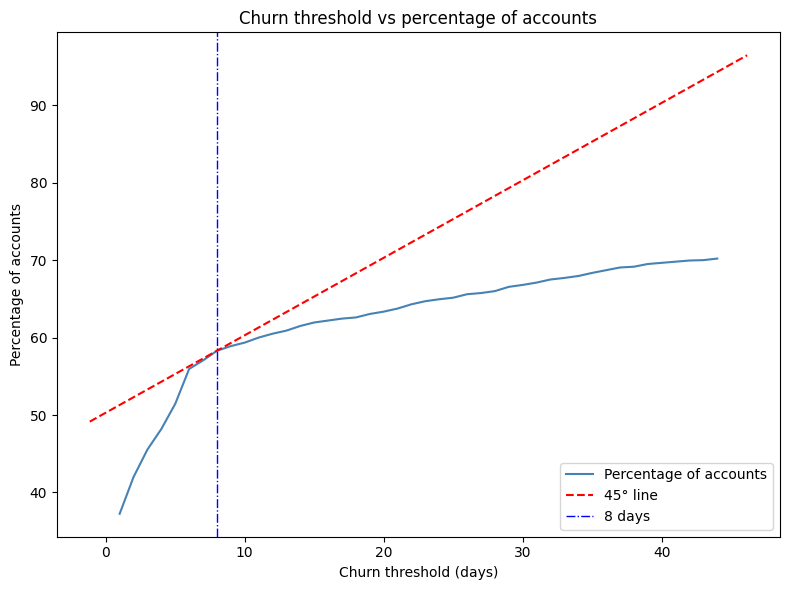

In [132]:
import numpy as np
import matplotlib.pyplot as plt

ax = df_churn_thresholds.plot(
    x='threshold_in_days',
    y='percentage_of_accounts',
    figsize=(8, 6),
    color='steelblue',
    label='Percentage of accounts'
)

# First point
x0 = df_churn_thresholds['threshold_in_days'].iloc[7]
y0 = df_churn_thresholds['percentage_of_accounts'].iloc[7]

# 45-degree line (slope = 1) through the first point
x = np.array(ax.get_xlim())
y = y0 + (x - x0)

ax.plot(x, y, '--', color='red', label='45° line')

ax.axvline(x0, color='blue', linestyle='-.', linewidth=1, label="{:} days".format(x0))

#ax.set_aspect('equal', adjustable='box')

ax.set_xlabel('Churn threshold (days)')
ax.set_ylabel('Percentage of accounts')
ax.set_title('Churn threshold vs percentage of accounts')
ax.legend()

plt.tight_layout()
plt.show()

The table above contains churn thresholds (1 - 45 days) vs percentage of churned accounts (users who never returned (considering until the date of the last activity only)). __8 days__ for the churn threshold seems to be a reasonable value as anything less than this might be disturbing for the customers.

In [133]:
df_churn_thresholds[:10]

,threshold_in_days,number_of_accounts,percentage_of_accounts
0,1,745,37.25
1,2,840,42.00
2,3,911,45.55
3,4,964,48.20
4,5,1029,51.45
5,6,1119,55.95
6,7,1141,57.05
7,8,1166,58.30
8,9,1178,58.90
9,10,1187,59.35


<div class="alert alert-block alert-info">
    <b>How did you choose to define churn and why?</b><br/>
    The last <i>summary_date</i> for each <i>accountid</i> represents the last day an activity each user has performed.<br/><br/>
    <b>A better definition of churn</b><br/>
    Early churn detection is essential, I would reduce the threshold of days since last action to 8 days
</div>

## Dataset preparation

In [139]:
extra_columns_to_be_kept = ['accountid', 'summary_date', 'is_churned', 'bet_type', 'category', 'secondary_product', 'foundation_category', 'account_tier', 'activity_channel', 'productgroup', 'registration_date', 'firstdeposit_createddate']

def prepare_dataset(df, churn_threshold, filtered_date_column, lower_bound, upper_bound):
    df['is_churned'] = np.where(
        df[filtered_date_column] <= churn_threshold,
        True,
        False
    )

    # Merging
    df_data_with_churn = pd.merge(
        df_raw,
        df[['accountid', 'is_churned']],
        how='left',
        on='accountid'
    )

    assert df_raw.shape[0] == df_data_with_churn.shape[0], "The size of the merged dataframes do not match"

    # Outlier filtering
    starting_entry_number = df_data_with_churn.shape[0]

    # Placed bets
    plc_turnover_gbp_ub = df_data_with_churn['plc_turnover_gbp'].quantile(upper_bound)
    df_data_with_churn = df_data_with_churn[df_data_with_churn['plc_turnover_gbp'] <= plc_turnover_gbp_ub].copy()

    plc_turnover_gbp_rcash_ub = df_data_with_churn['plc_turnover_gbp_rcash'].quantile(upper_bound)
    df_data_with_churn = df_data_with_churn[df_data_with_churn['plc_turnover_gbp_rcash'] <= plc_turnover_gbp_rcash_ub].copy()

    plc_turnover_gbp_bonus_ub = df_data_with_churn['plc_turnover_gbp_bonus'].quantile(upper_bound)
    df_data_with_churn = df_data_with_churn[df_data_with_churn['plc_turnover_gbp_bonus'] <= plc_turnover_gbp_bonus_ub].copy()

    plc_betcount_ub = df_data_with_churn['plc_betcount'].quantile(upper_bound)
    df_data_with_churn = df_data_with_churn[df_data_with_churn['plc_betcount'] <= plc_betcount_ub].copy()
    

    # Settled bets
    stl_turnover_gbp_ub = df_data_with_churn['stl_turnover_gbp'].quantile(upper_bound)
    df_data_with_churn = df_data_with_churn[df_data_with_churn['stl_turnover_gbp'] <= stl_turnover_gbp_ub].copy()

    stl_turnover_gbp_rcash_ub = df_data_with_churn['stl_turnover_gbp_rcash'].quantile(upper_bound)
    df_data_with_churn = df_data_with_churn[df_data_with_churn['stl_turnover_gbp_rcash'] <= stl_turnover_gbp_rcash_ub].copy()

    stl_turnover_gbp_bonus_ub = df_data_with_churn['stl_turnover_gbp_bonus'].quantile(upper_bound)
    df_data_with_churn = df_data_with_churn[df_data_with_churn['stl_turnover_gbp_bonus'] <= stl_turnover_gbp_bonus_ub].copy()

    stl_betcount_ub = df_data_with_churn['stl_betcount'].quantile(upper_bound)
    df_data_with_churn = df_data_with_churn[df_data_with_churn['stl_betcount'] <= stl_betcount_ub].copy()


    # Settled Gross Gaming Revenue
    stl_ggr_gbp_ub = df_data_with_churn['stl_ggr_gbp'].quantile(upper_bound)
    stl_ggr_gbp_lb = df_data_with_churn['stl_ggr_gbp'].quantile(lower_bound)
    df_data_with_churn = df_data_with_churn[
        (stl_ggr_gbp_lb <= df_data_with_churn['stl_ggr_gbp']) &
        (df_data_with_churn['stl_ggr_gbp'] <= stl_ggr_gbp_ub)
    ].copy()

    stl_ggr_gbp_rcash_ub = df_data_with_churn['stl_ggr_gbp_rcash'].quantile(upper_bound)
    stl_ggr_gbp_rcash_lb = df_data_with_churn['stl_ggr_gbp_rcash'].quantile(lower_bound)
    df_data_with_churn = df_data_with_churn[
        (stl_ggr_gbp_lb <= df_data_with_churn['stl_ggr_gbp_rcash']) &
        (df_data_with_churn['stl_ggr_gbp_rcash'] <= stl_ggr_gbp_ub)
    ].copy()

    stl_ggr_gbp_bonus_ub = df_data_with_churn['stl_ggr_gbp_bonus'].quantile(upper_bound)
    stl_ggr_gbp_bonus_lb = df_data_with_churn['stl_ggr_gbp_bonus'].quantile(lower_bound)
    df_data_with_churn = df_data_with_churn[
        (stl_ggr_gbp_bonus_lb <= df_data_with_churn['stl_ggr_gbp_bonus']) &
        (df_data_with_churn['stl_ggr_gbp_bonus'] <= stl_ggr_gbp_bonus_ub)
    ].copy()

    deposit_gbp_ub = df_data_with_churn['deposit_gbp'].quantile(upper_bound)
    deposit_gbp_lb = df_data_with_churn['deposit_gbp'].quantile(lower_bound)
    df_data_with_churn = df_data_with_churn[
        (deposit_gbp_lb <= df_data_with_churn['deposit_gbp']) &
        (df_data_with_churn['deposit_gbp'] <= deposit_gbp_ub)
    ].copy()

    withdrawal_gbp_ub = df_data_with_churn['withdrawal_gbp'].quantile(upper_bound)
    withdrawal_gbp_lb = df_data_with_churn['withdrawal_gbp'].quantile(lower_bound)
    df_data_with_churn = df_data_with_churn[
        (withdrawal_gbp_lb <= df_data_with_churn['withdrawal_gbp']) &
        (df_data_with_churn['withdrawal_gbp'] <= withdrawal_gbp_ub)
    ].copy()

    df_output = df_data_with_churn[extra_columns_to_be_kept + activity_columns].copy()

    print("Removed {:,} outliers".format(
        starting_entry_number - df_output.shape[0]
    ))
    return df_output


In [144]:
DAYS_THRESHOLD = 8
UPPER_BOUND = 0.9999
LOWER_BOUND = 0.0001

df_filtered = prepare_dataset(account_summary_date_diff, DAYS_THRESHOLD, 'days_till_2022_12_31', upper_bound=UPPER_BOUND, lower_bound=LOWER_BOUND)

Removed 723 outliers


In [145]:
df_filtered[:5]

,accountid,summary_date,is_churned,bet_type,category,secondary_product,foundation_category,account_tier,activity_channel,productgroup,...,plc_turnover_gbp_bonus,stl_betcount,stl_turnover_gbp,stl_turnover_gbp_rcash,stl_turnover_gbp_bonus,stl_ggr_gbp,stl_ggr_gbp_rcash,stl_ggr_gbp_bonus,deposit_gbp,withdrawal_gbp
0,667707849,2021-07-19,False,<NA>,<NA>,<NA>,NewPlayer,NEW,<NA>,<NA>,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0
1,667574815,2021-07-19,False,<NA>,eGaming,<NA>,NewPlayer,WINNERS,<NA>,<NA>,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,667338216,2021-07-19,False,<NA>,Sports,<NA>,NewPlayer,LOW,<NA>,<NA>,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,667183293,2021-07-19,False,Single,Sports,Badminton,NewPlayer,Premium,Desktop,Sportsbook,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,667037144,2021-07-19,False,<NA>,eGaming,<NA>,Paint,MEDIUM,<NA>,<NA>,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [146]:
df_filtered[activity_columns].select_dtypes(include="number").corr()

,plc_betcount,plc_turnover_gbp,plc_turnover_gbp_rcash,plc_turnover_gbp_bonus,stl_betcount,stl_turnover_gbp,stl_turnover_gbp_rcash,stl_turnover_gbp_bonus,stl_ggr_gbp,stl_ggr_gbp_rcash,stl_ggr_gbp_bonus,deposit_gbp,withdrawal_gbp
plc_betcount,1.000000,0.569481,0.569351,0.041408,0.999939,0.569586,0.569457,0.041366,0.020700,0.020490,0.009976,-0.069349,-0.040167
plc_turnover_gbp,0.569481,1.000000,0.999963,0.050756,0.569430,0.998197,0.998163,0.050388,0.004539,0.003980,0.026236,-0.052813,-0.030590
plc_turnover_gbp_rcash,0.569351,0.999963,1.000000,0.042128,0.569300,0.998162,0.998201,0.041957,0.004424,0.003950,0.022302,-0.052634,-0.030486
plc_turnover_gbp_bonus,0.041408,0.050756,0.042128,1.000000,0.041376,0.050487,0.042049,0.977154,0.013415,0.003700,0.456131,-0.023111,-0.013386
stl_betcount,0.999939,0.569430,0.569300,0.041376,1.000000,0.569605,0.569476,0.041404,0.020718,0.020507,0.010045,-0.069346,-0.040166
stl_turnover_gbp,0.569586,0.998197,0.998162,0.050487,0.569605,1.000000,0.999963,0.050866,0.007441,0.006866,0.027029,-0.052819,-0.030594
stl_turnover_gbp_rcash,0.569457,0.998163,0.998201,0.042049,0.569476,0.999963,1.000000,0.042230,0.007323,0.006839,0.022746,-0.052641,-0.030490
stl_turnover_gbp_bonus,0.041366,0.050388,0.041957,0.977154,0.041404,0.050866,0.042230,1.000000,0.014020,0.003456,0.495969,-0.023077,-0.013366
stl_ggr_gbp,0.020700,0.004539,0.004424,0.013415,0.020718,0.007441,0.007323,0.014020,1.000000,0.999773,0.016491,-0.011678,-0.006764
stl_ggr_gbp_rcash,0.020490,0.003980,0.003950,0.003700,0.020507,0.006866,0.006839,0.003456,0.999773,1.000000,-0.004809,-0.011181,-0.006476


| Term               | Meaning                                                                                  | Includes                                                                                                             |
| ------------------ | ---------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------- |
| **Placed stakes**  | The total amount wagered when customers place their bets.                                | All bets that have been accepted, regardless of whether they are still open, won, lost, voided, or cashed out later. |
| **Settled stakes** | The total stake amount for bets that have reached a final outcome during a given period. | Only bets that have been resolved (won, lost, voided, etc.). Open bets are excluded until they settle.               |


In [147]:
filename = 'output/dataset_churn_labeled_th{:}_pr{:}_{:%Y%m%d}.csv'.format(
    DAYS_THRESHOLD,
    len(str(UPPER_BOUND))-2,
    datetime.datetime.now()
)
df_filtered.to_csv(filename, index=False)
print("File saved to `{:}`".format(filename))

File saved to `output/dataset_churn_labeled_th8_pr4_20260609.csv`
